In [ ]:
import sys
sys.path.append('../../')

from src import utils
import src.channelCoding as cc
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# MongoDB connection


client = MongoClient('mongodb://localhost:27017/')
db = client['r0_r1_SC_alpha_0_5_R=0_5_Encryption']

# TARGET_MAC = '3f8cd3da0bf84566839a7c790889884bab003e2de42c45d822188c14e1fbb719'
# MESSAGE = "This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of "
print(client.list_database_names())
for db_name in client.list_database_names():

    db = client[db_name]
    phase_SC_col = db['destination, phase_1']
    
    try:
        df = phase_SC_col.find_one({})
        df['r0'] 
        print('r_0: ', db_name)
        max_snr = phase_SC_col.find_one(sort=[("SNR", -1)])["SNR"]
        print("Max SNR:", max_snr)

    except:
        try:
            df['llr']
            print('llr: ', db_name)
            max_snr = phase_SC_col.find_one(sort=[("SNR", -1)])["SNR"]
            print("Max SNR:", max_snr)
        except:
            pass
    
            



In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import Normalize
import src.rx

# Global style tweaks – run once
plt.rcParams.update({
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "axes.titlesize": 22,
    "axes.linewidth": 1.4,
    "font.family": "serif",
})

def plot_histograms(df):
    sns.set_theme(style="whitegrid", context="talk")

    df = df.sort_values(by='SNR', ascending=True)

    for idx in np.linspace( 0, 59220, 40, dtype=int):
        try:
            row = df.iloc[idx]
            snr_linear = 10**(row['SNR']/10)
            alpha = row['config']['ALPHA']

            class conf:
                def __init__(self):
                    self.LPF_CUTOFF = row['config']['LPF_CUTOFF']
                    self.RX_RATE = row['config']['RX_RATE']
                    self.ALPHA = row['config']['ALPHA']

            # demod = src.rx.Demodulation(conf=conf())

            fig, ax = plt.subplots(figsize=(5, 3.6), dpi=340)

            # -------- thresholds ----------
            thr_pos = (np.log10(((1-alpha)*snr_linear + 1)/(alpha*snr_linear + 1))
                       + np.log10(1 + snr_linear)) / 2
            thr_neg = (np.log10((alpha*snr_linear + 1)/((1-alpha)*snr_linear + 1))
                       - np.log10(1 + snr_linear)) / 2
            print(f"SNR: {row['SNR']} dB")
            data = np.log10(np.array(row['r0']) / np.array(row['r1']))

            # -------- gradient histogram (|z|) ----------
            bins = 90
            counts, edges = np.histogram(data, bins=bins)
            centers = 0.5 * (edges[:-1] + edges[1:])

            # symmetric normalisation on |z|
            norm = Normalize(vmin=0, vmax=np.max(np.abs(centers)))
            cmap = plt.get_cmap("twilight_shifted")  # nice diverging colormap

            for c, left, right, center in zip(counts, edges[:-1], edges[1:], centers):
                if c == 0:
                    continue
                color = cmap(norm(abs(center)))
                ax.bar(center, c,
                       width=right - left,
                       color=color,
                       edgecolor="none",
                       align="center",
                       alpha=0.95,
                       zorder=1)

            # colorbar
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            # cbar = fig.colorbar(sm, ax=ax, pad=0.01)
            # cbar.set_label(r"$|z|$", fontsize=18)
            # cbar.ax.tick_params(labelsize=14)

            # -------- threshold lines & labels ----------
            # ax.text(-3, counts.max() * 0.95, r"$\gamma =$" + f"{np.round(row['SNR'], 1)} dB",
            #         fontsize=20, color="black", ha='left', va='top',
            #         bbox=dict(facecolor='white', edgecolor='#344a6c', boxstyle='round,pad=0.25'),
            #         rotation=0,  # Rotate the text 90 degrees
            #         zorder=4)

            ax.axvline(thr_pos, ls="--", lw=2.3, color="#2ca02c",
                       label=r"$\theta_2$", zorder=3)
            ax.axvline(thr_neg, ls="--", lw=2.3, color="#d62728",
                       label=r"$\theta_1$", zorder=3)

            y_max = counts.max() if counts.size > 0 else 1

            ax.text(thr_pos, y_max * 0.98, r"$\theta_2$",
                    color="#2ca02c", fontsize=16,
                    bbox=dict(facecolor='white', edgecolor='#2ca02c',
                              boxstyle='round,pad=0.25'),
                    ha='center', va='top', zorder=4)
            ax.text(thr_neg, y_max * 0.98, r"$\theta_1$",
                    color="#d62728", fontsize=16,
                    bbox=dict(facecolor='white', edgecolor='#d62728',
                              boxstyle='round,pad=0.25'),
                    ha='center', va='top', zorder=4)

            # -------- axes / grid / legend ----------
            ax.set_xlabel(r"$z = \log_{10}(E_1/E_0)$")
            # ax.set_ylabel("Count")

            ax.set_xlim([-3.3, 3.3])
            ax.set_xticks(np.arange(-3, 4, 1))

            # a bit fewer y-ticks for a cleaner look
            ax.yaxis.set_major_locator(plt.MaxNLocator(6))

            # soften grid
            ax.grid(alpha=0.2, linewidth=0.7)

            # move legend slightly inside and de-frame it
            leg = ax.legend(frameon=True, loc="upper right")
            leg.get_frame().set_alpha(0.9)

            fig.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error processing index {idx}: {e}")
            continue


SNR: 1.8755098581314087 dB


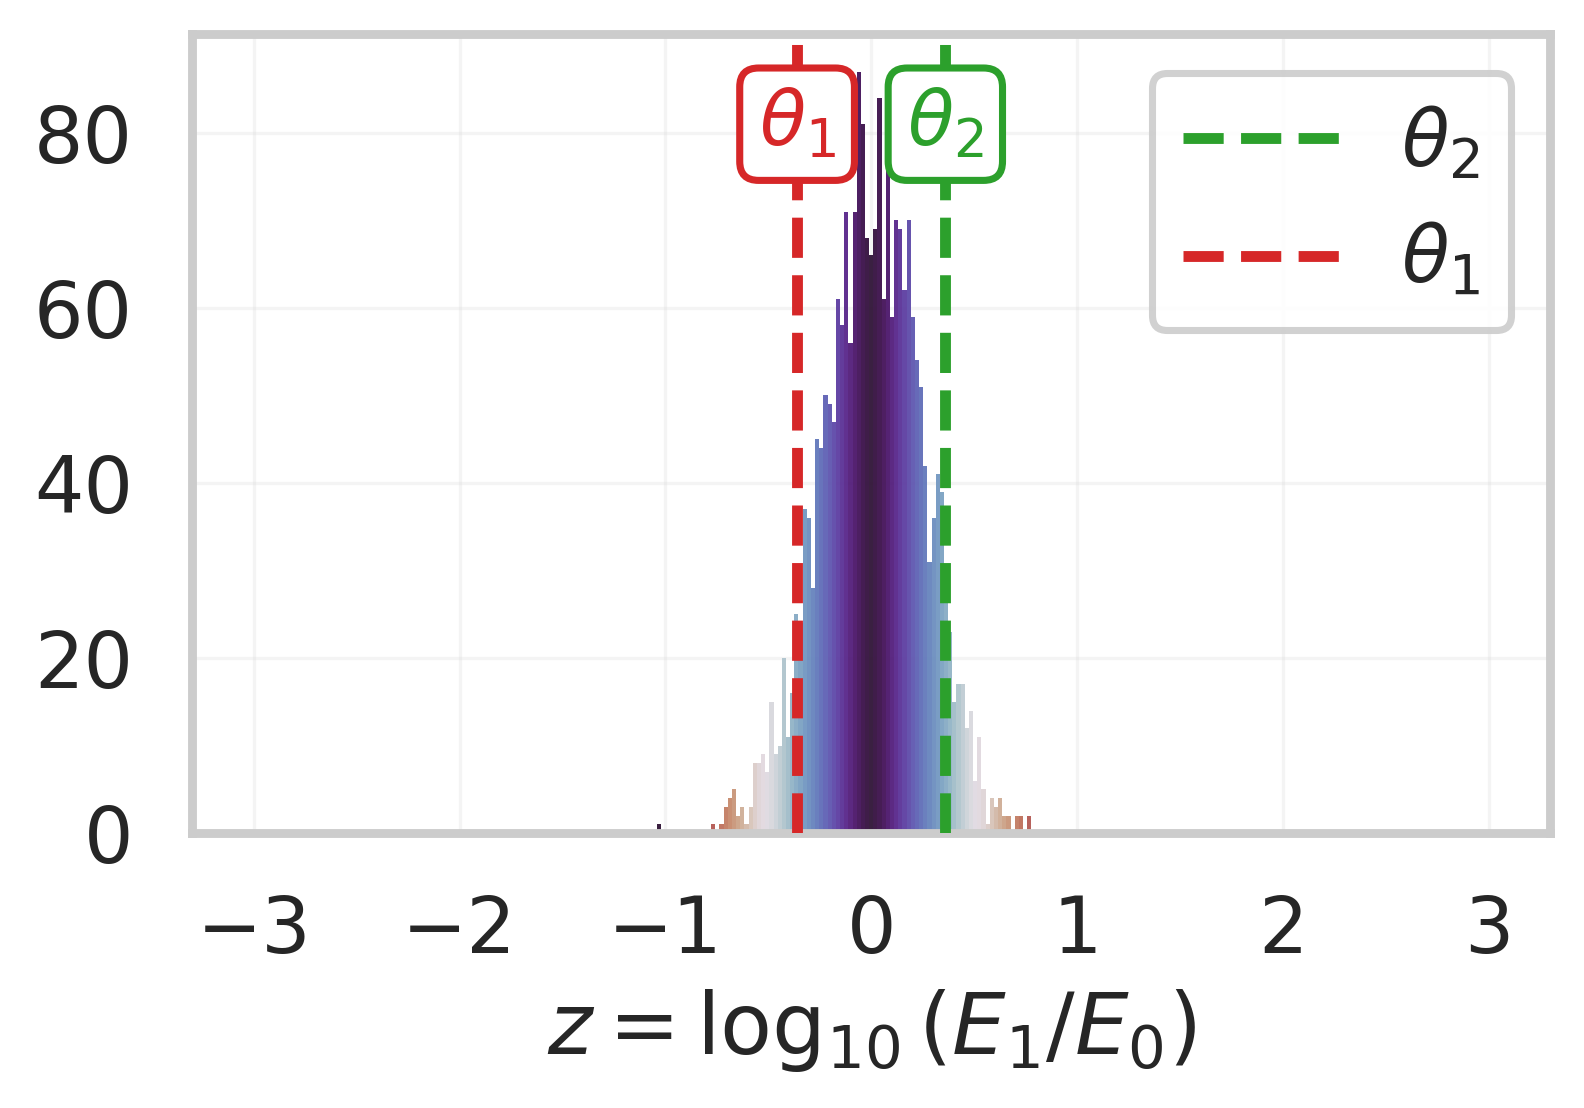

SNR: 3.271873950958252 dB


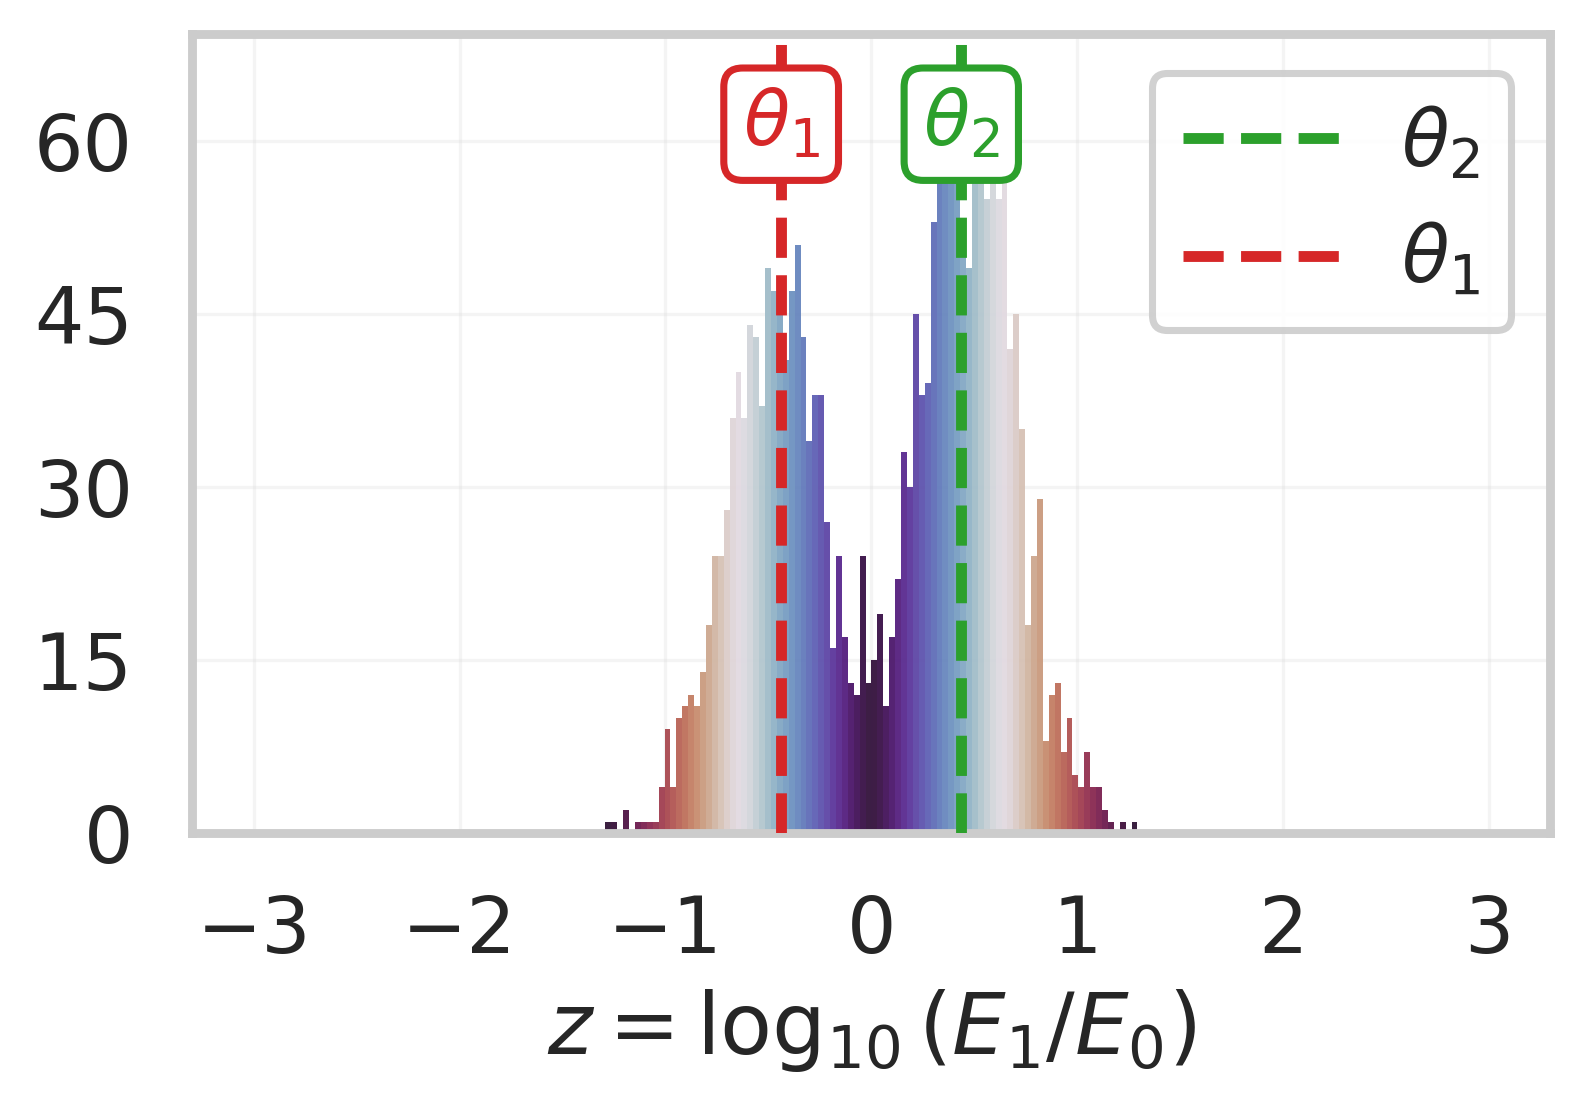

SNR: 3.6803691387176514 dB


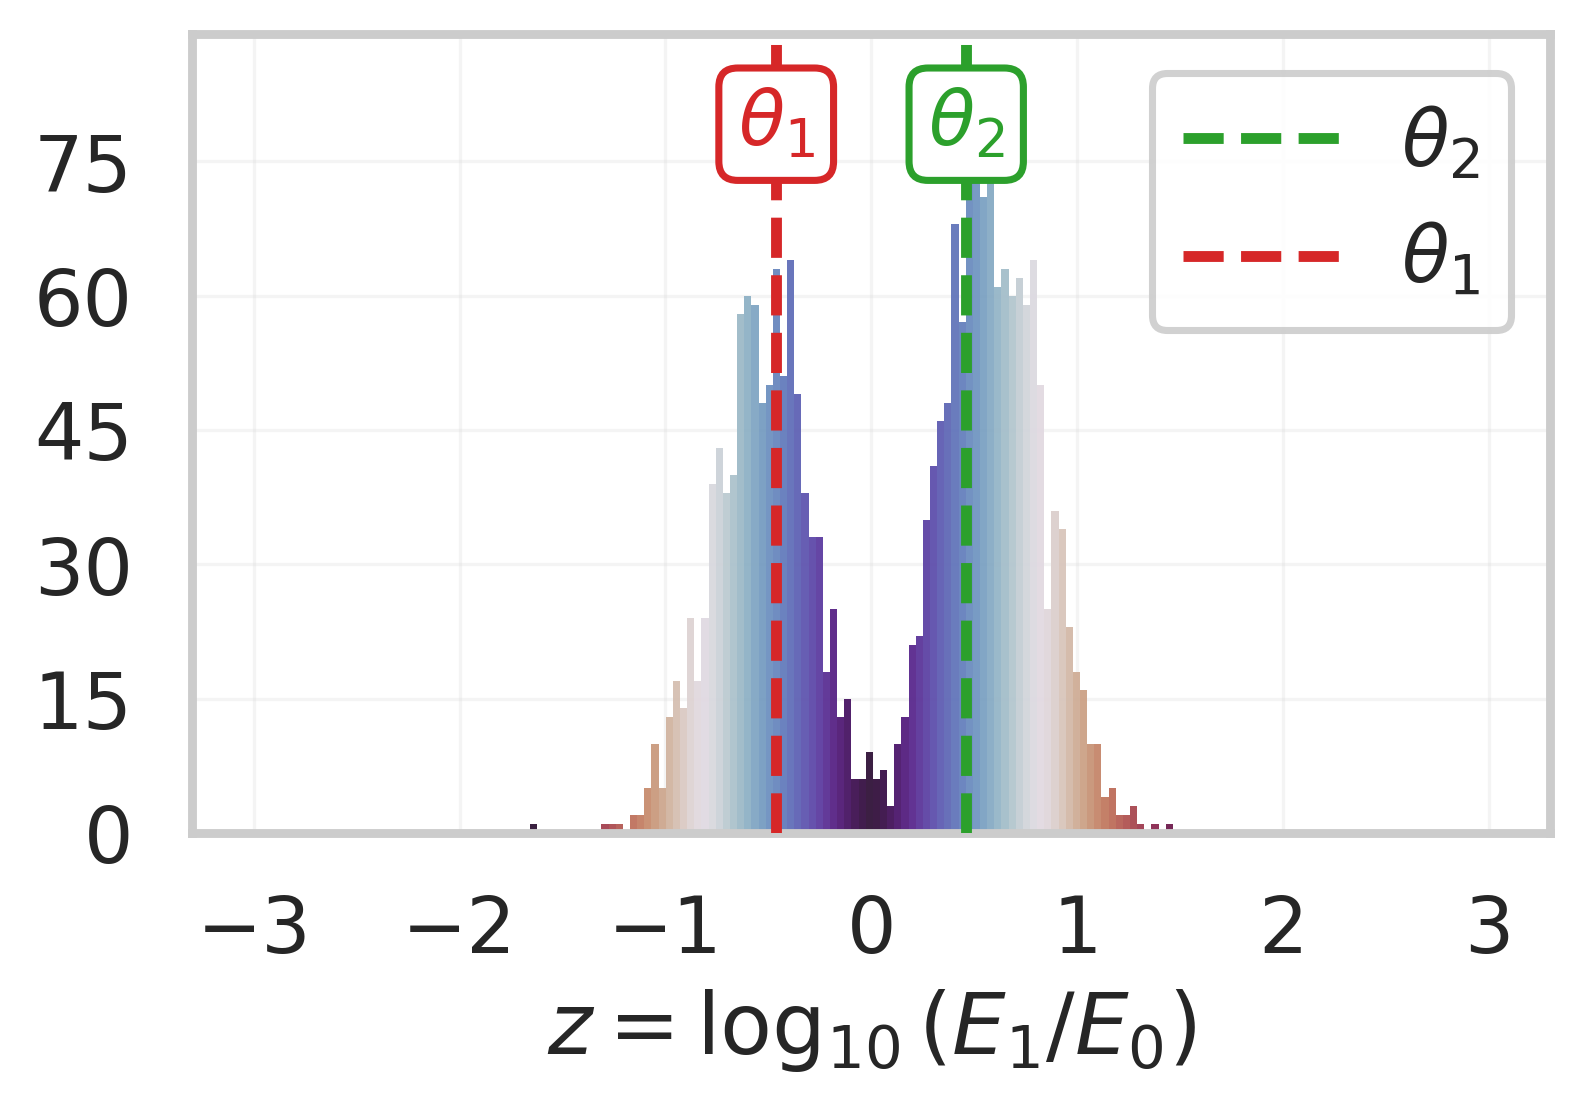

SNR: 3.9314942359924316 dB


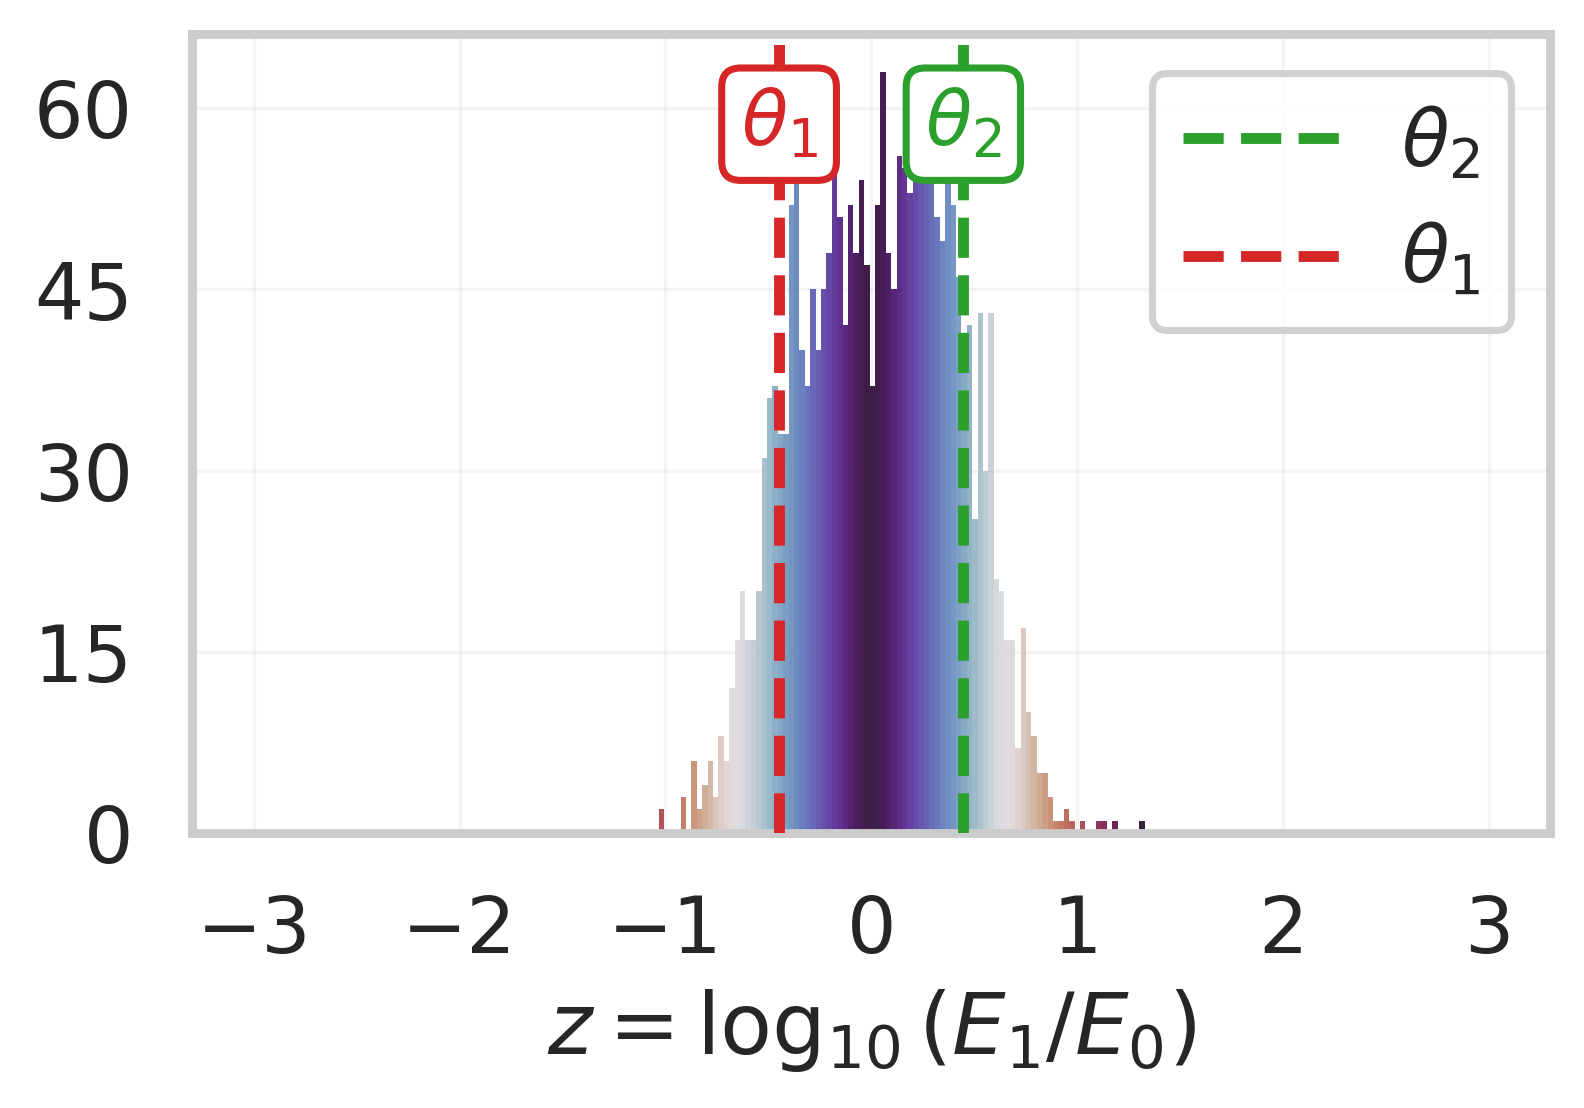

SNR: 4.094541549682617 dB


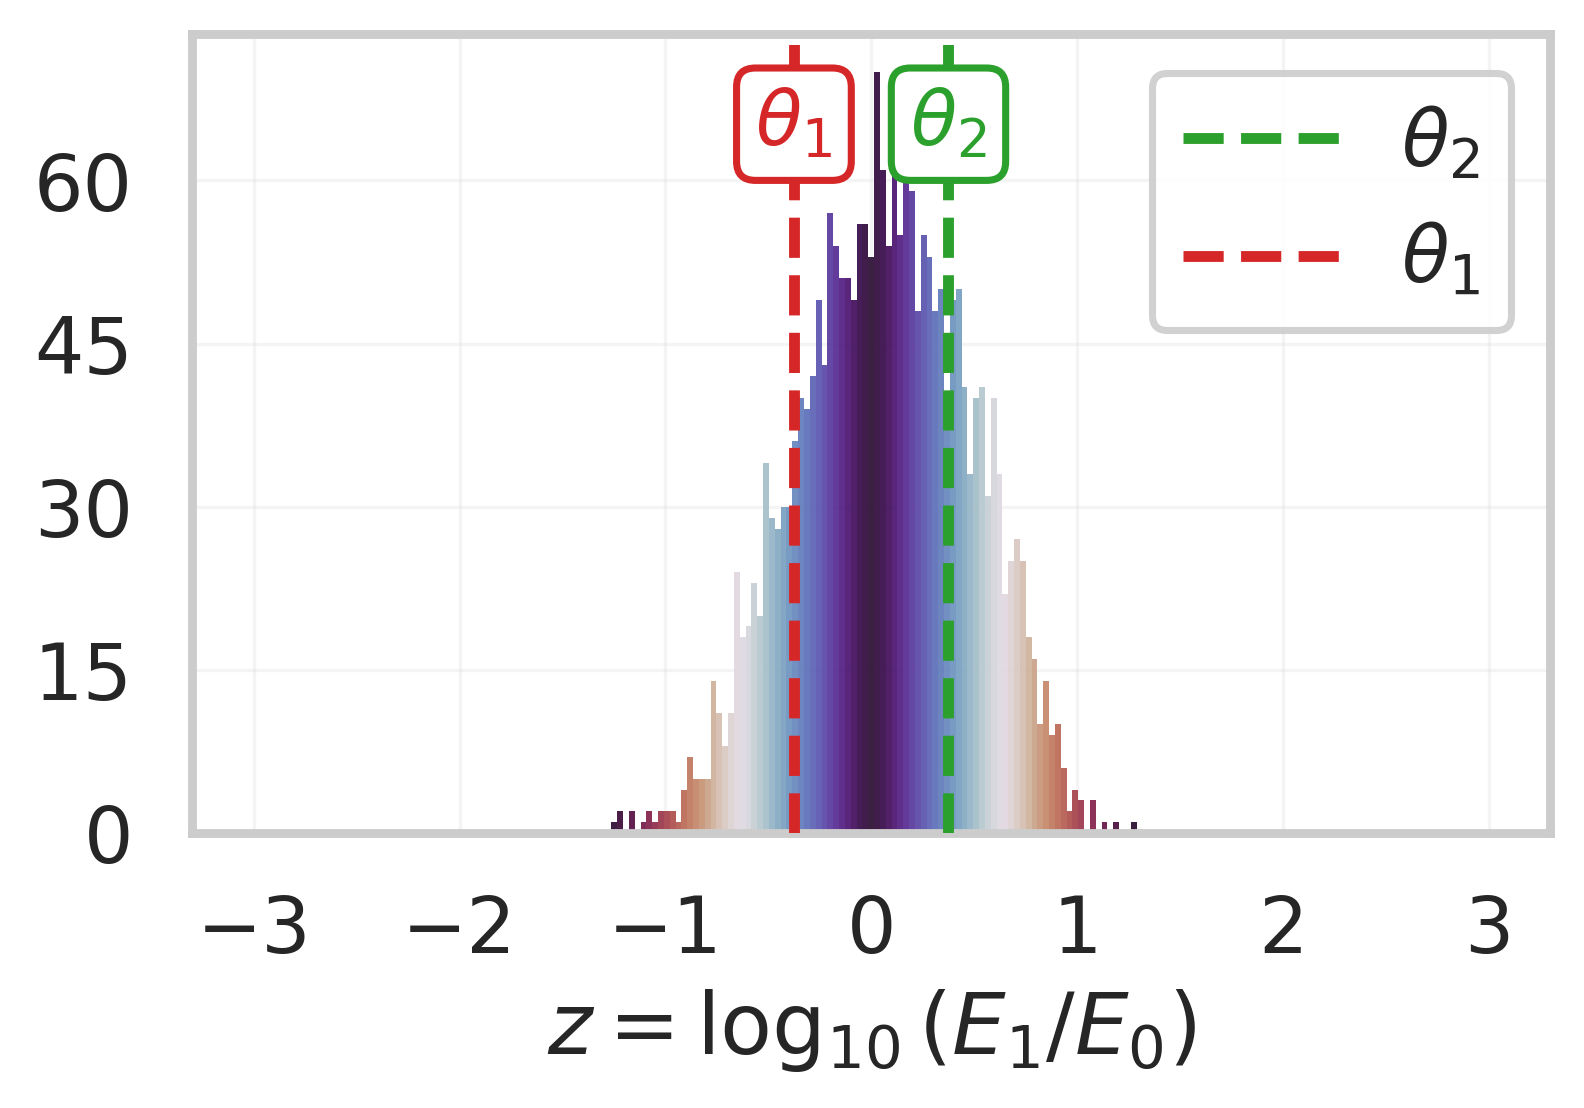

SNR: 4.483760833740234 dB


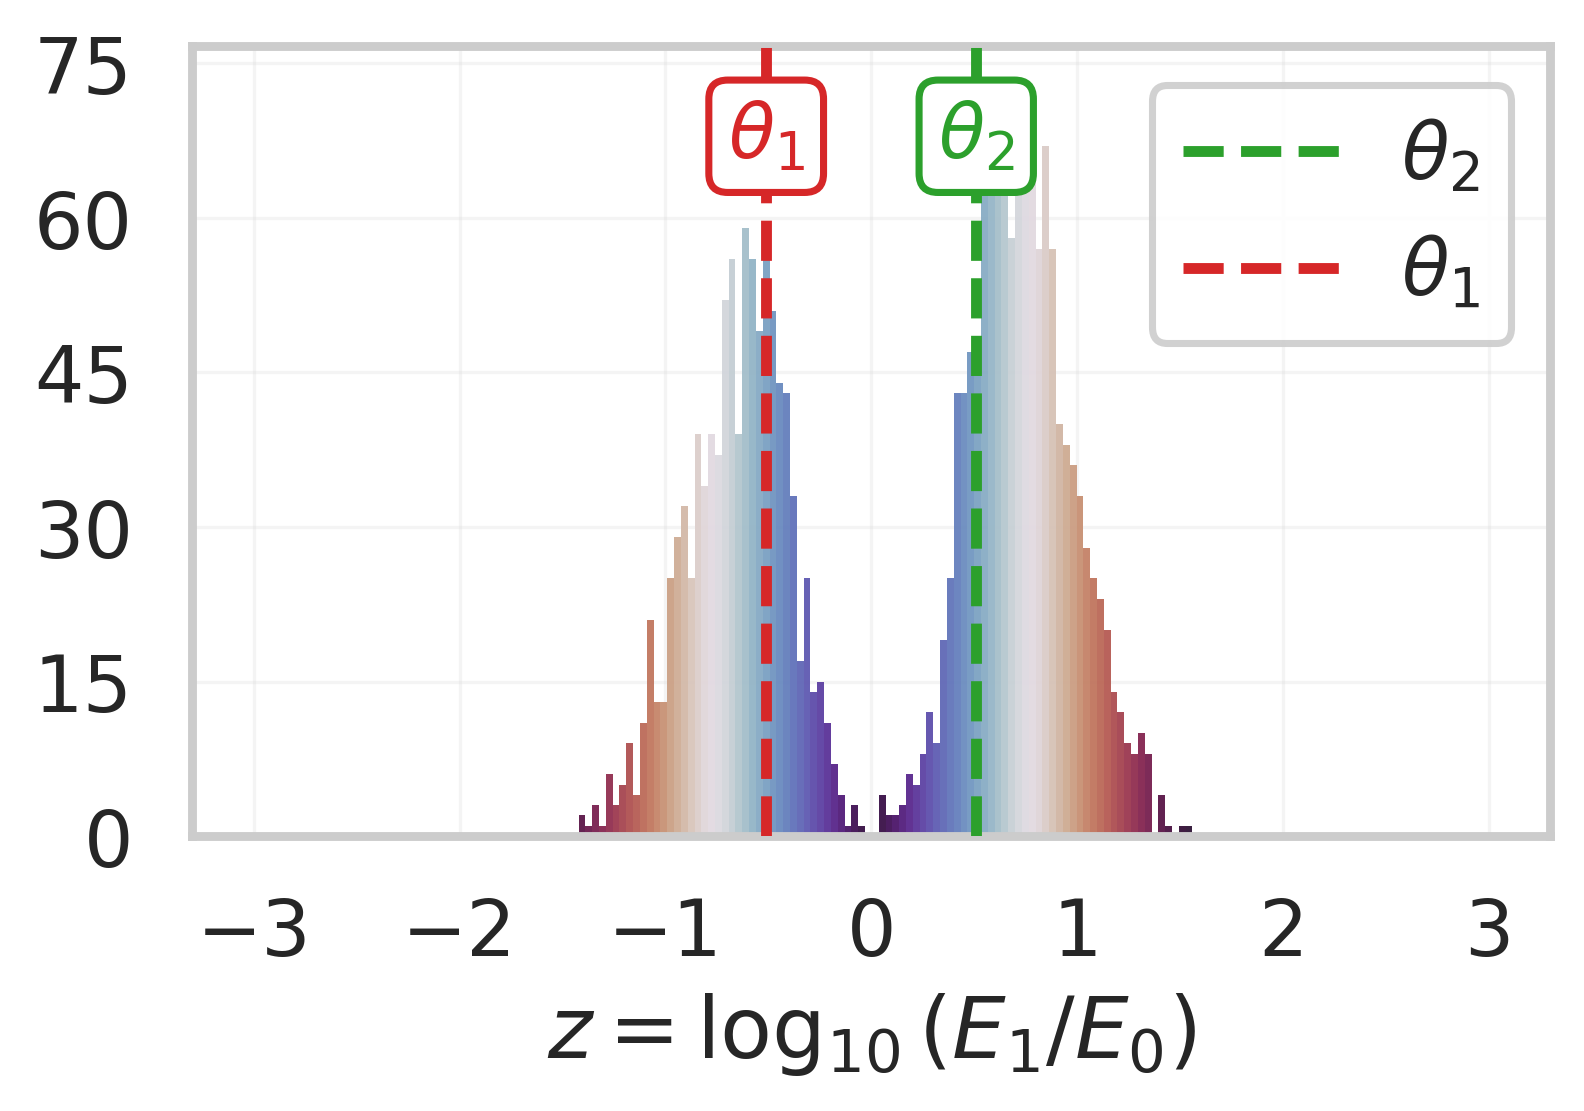

SNR: 4.814131259918213 dB


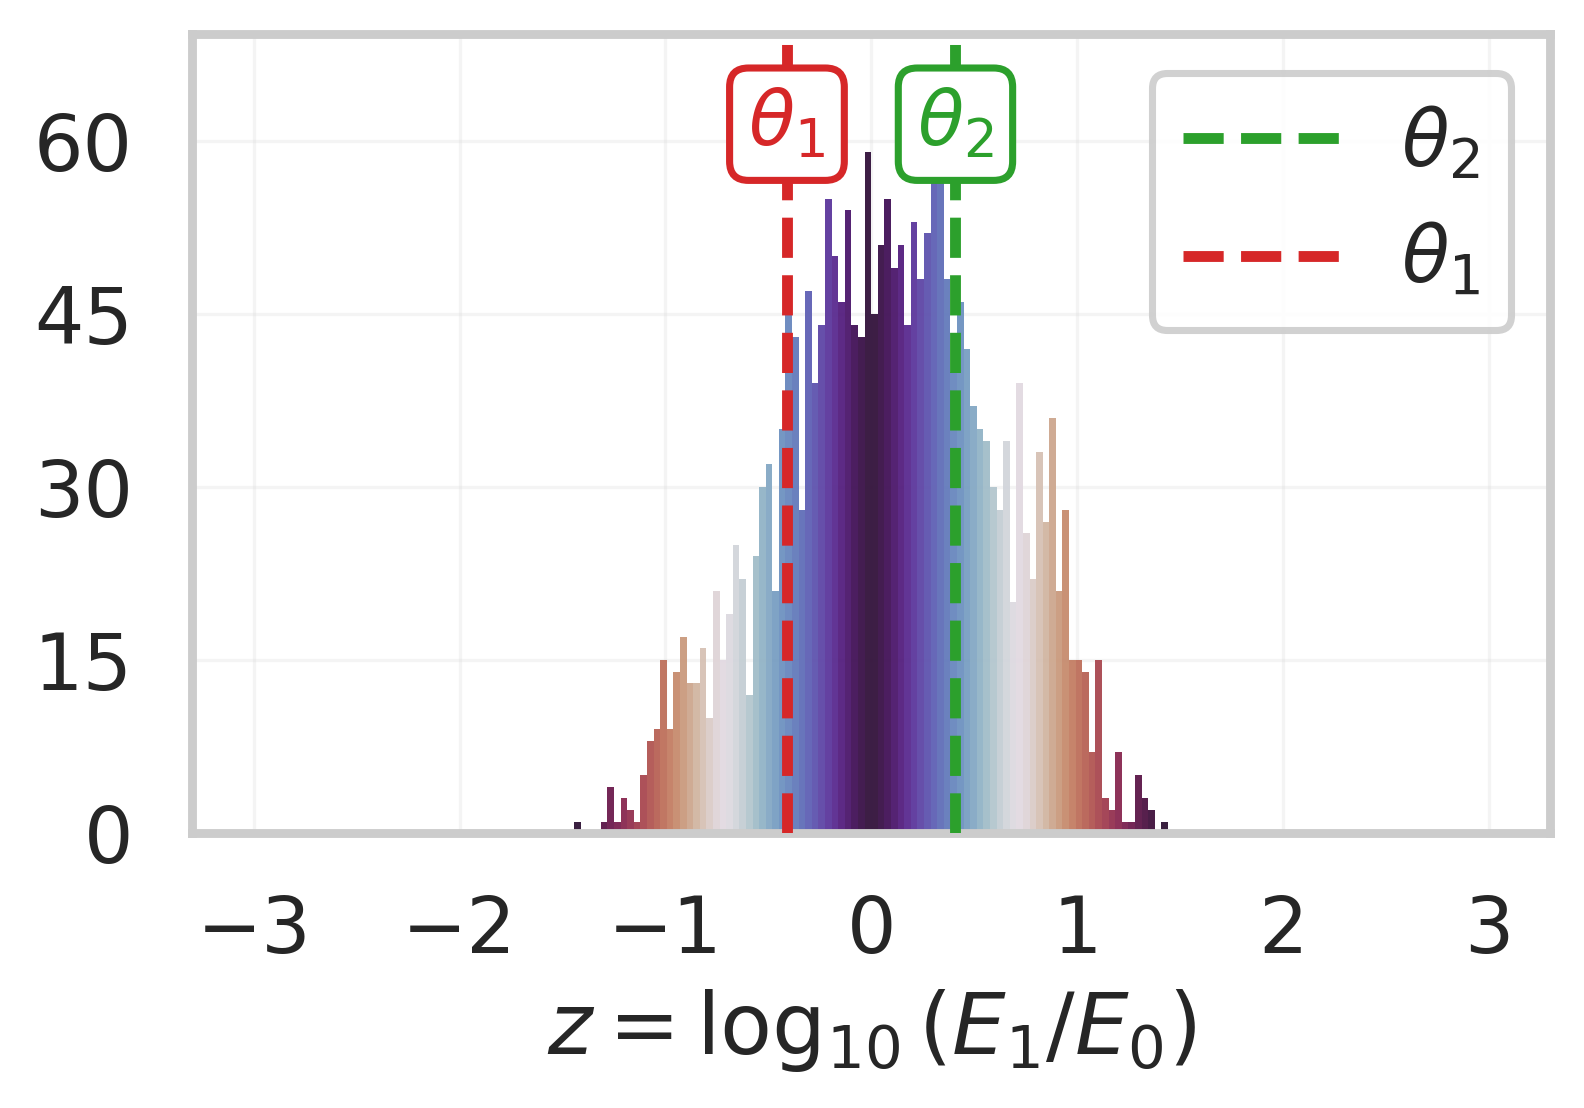

SNR: 5.153191089630127 dB


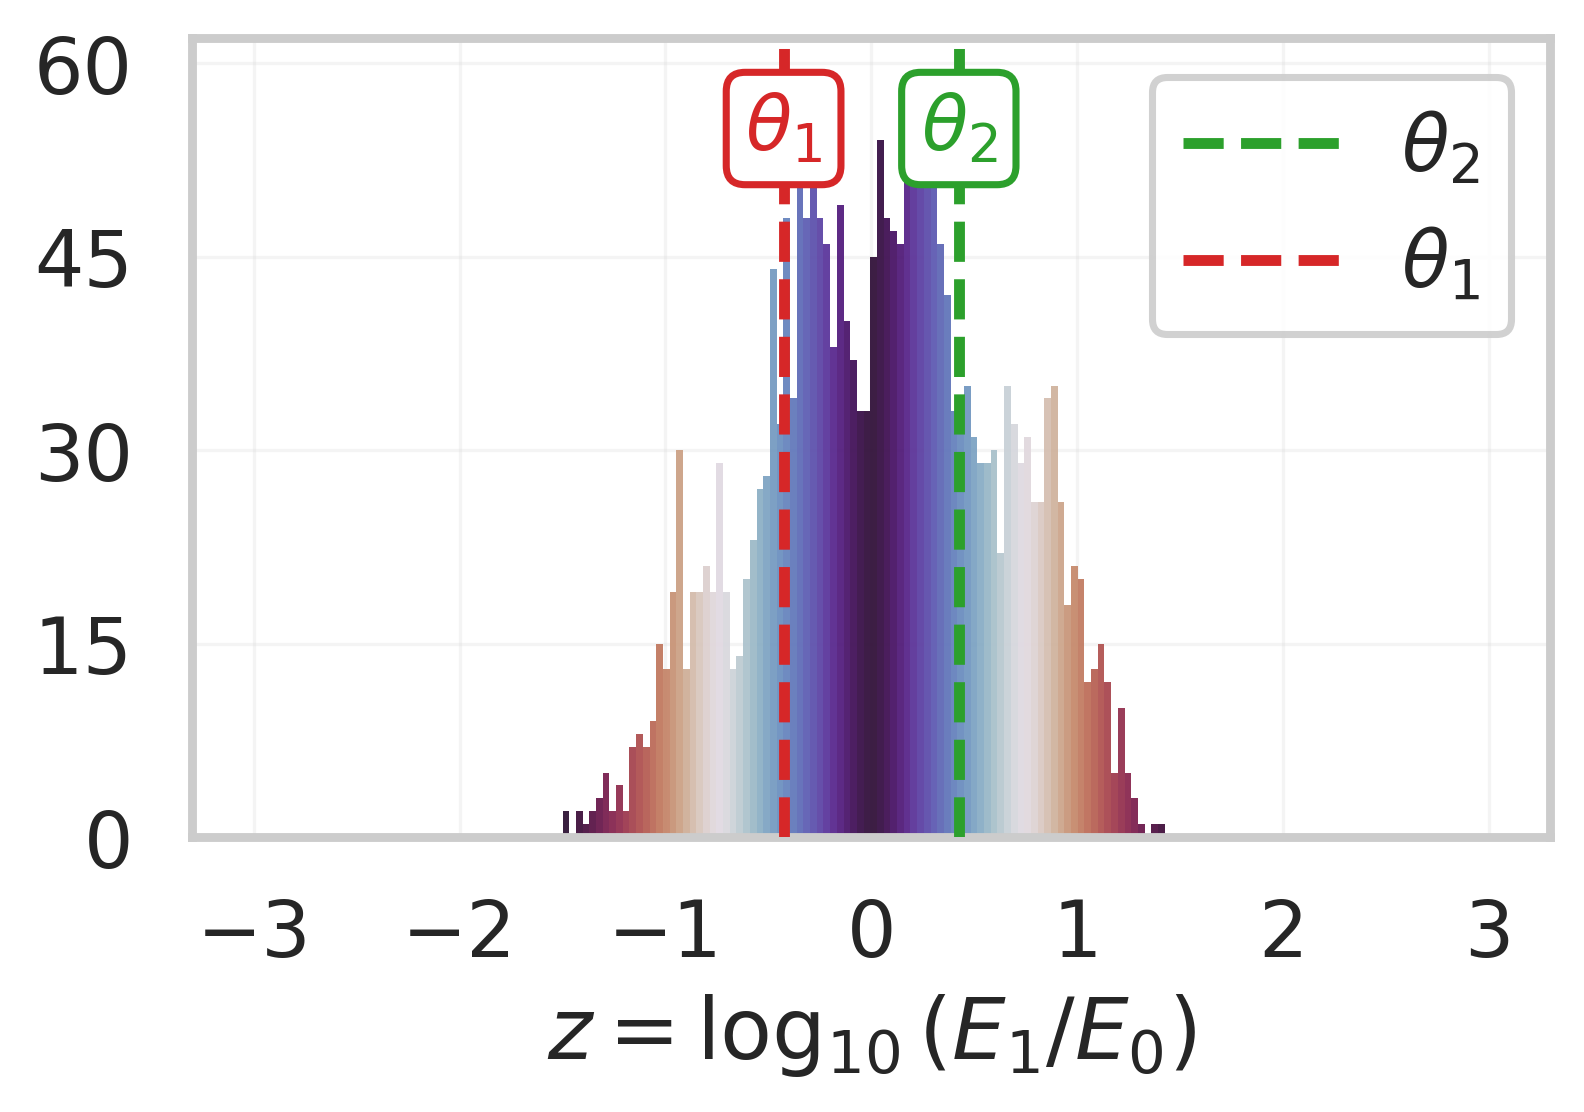

Error processing index 12147: 'float' object is not subscriptable
Error processing index 13666: 'float' object is not subscriptable
Error processing index 15184: 'float' object is not subscriptable
Error processing index 16703: 'float' object is not subscriptable
Error processing index 18221: 'float' object is not subscriptable
Error processing index 19740: 'float' object is not subscriptable
Error processing index 21258: 'float' object is not subscriptable
Error processing index 22776: 'float' object is not subscriptable
Error processing index 24295: 'float' object is not subscriptable
SNR: 6.716670513153076 dB


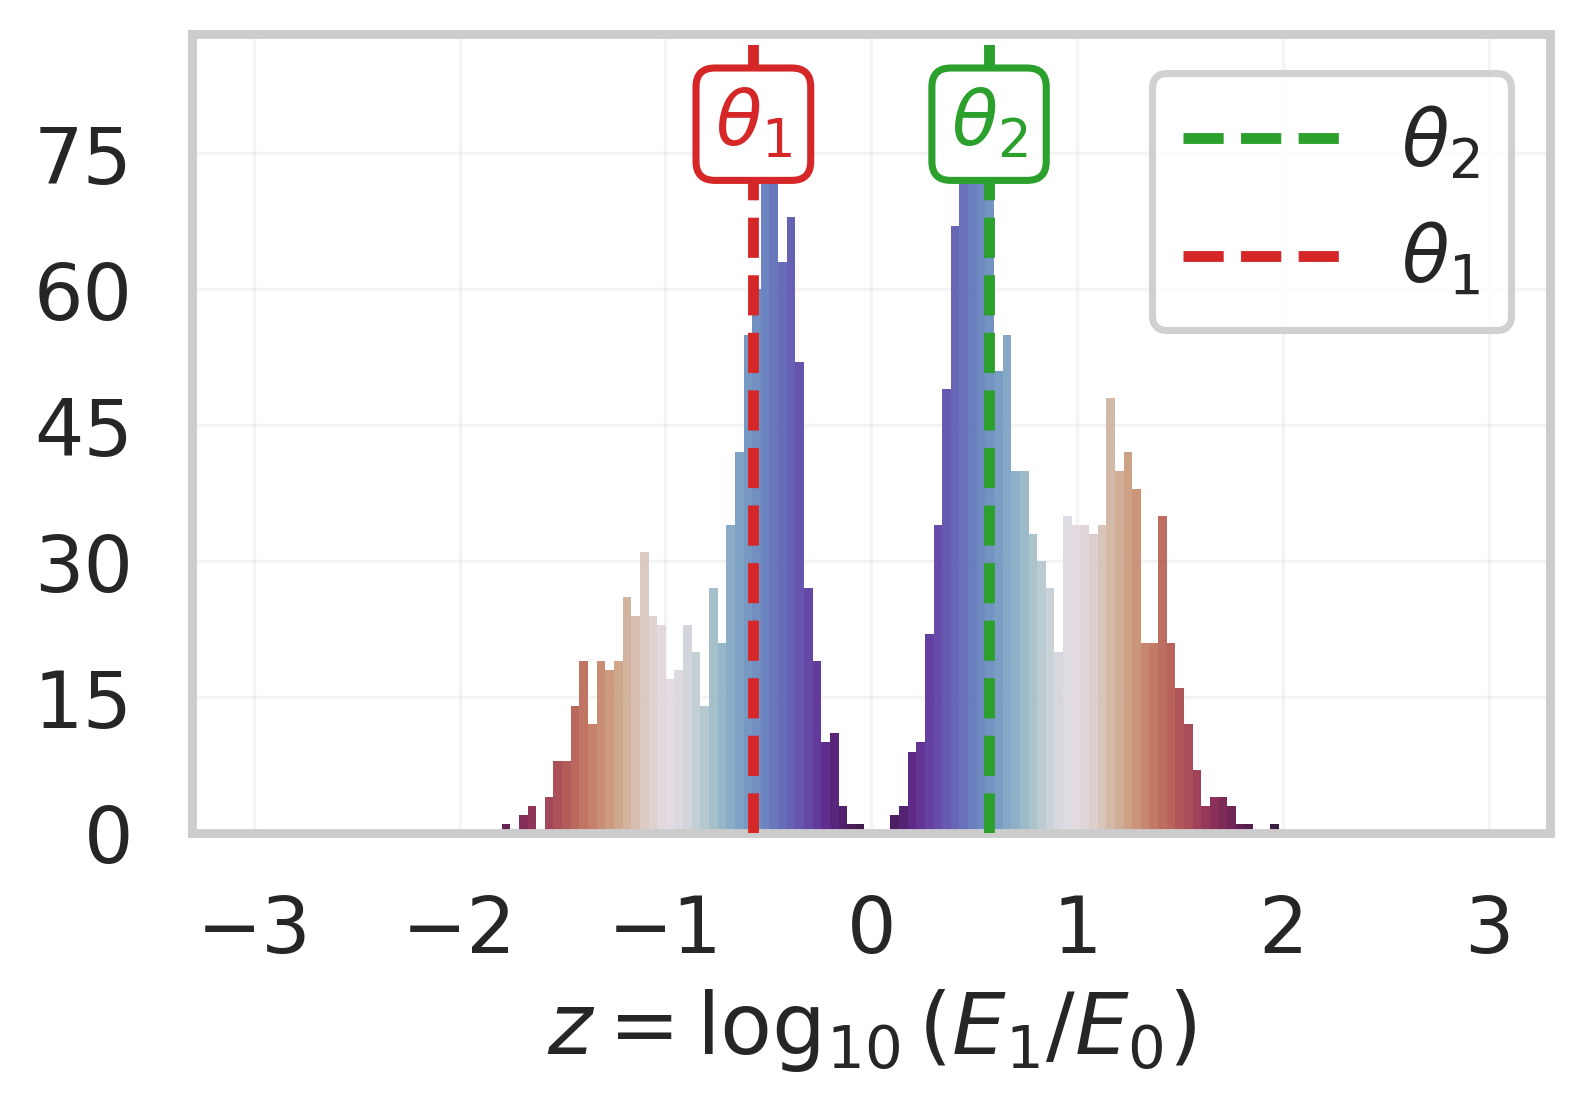

Error processing index 27332: 'float' object is not subscriptable
SNR: 7.274476051330566 dB


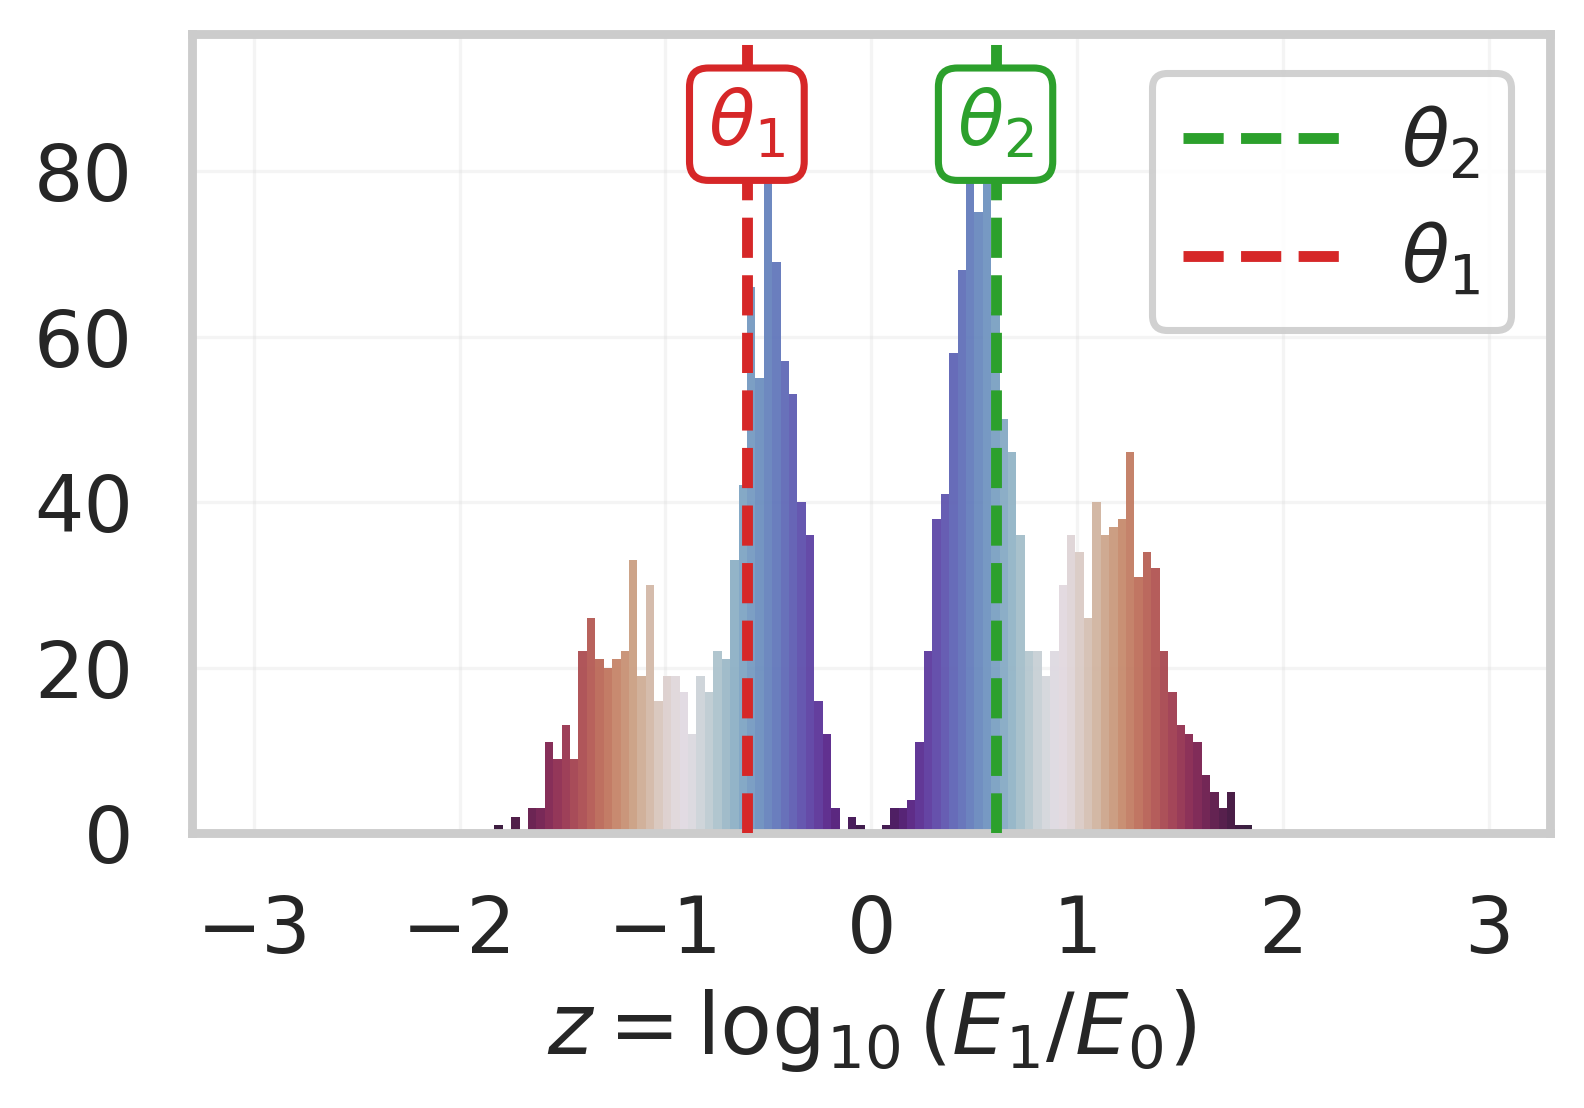

Error processing index 30369: 'float' object is not subscriptable
SNR: 7.563500881195068 dB


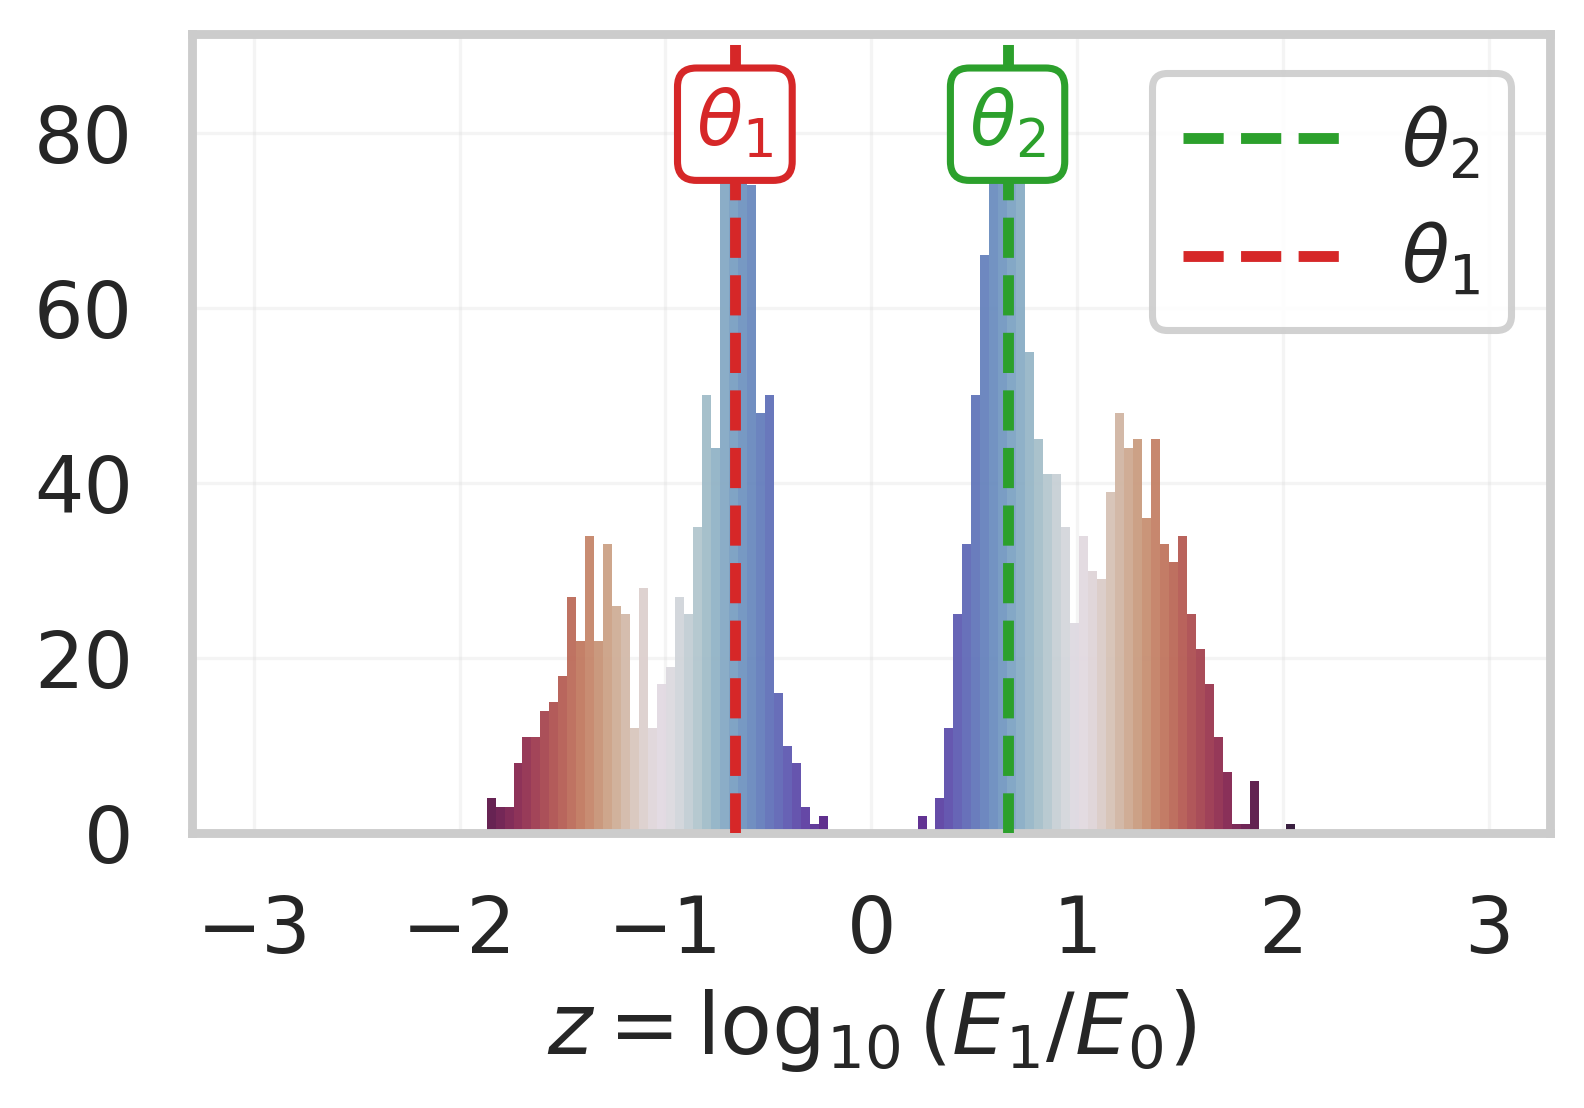

SNR: 7.6095662117004395 dB


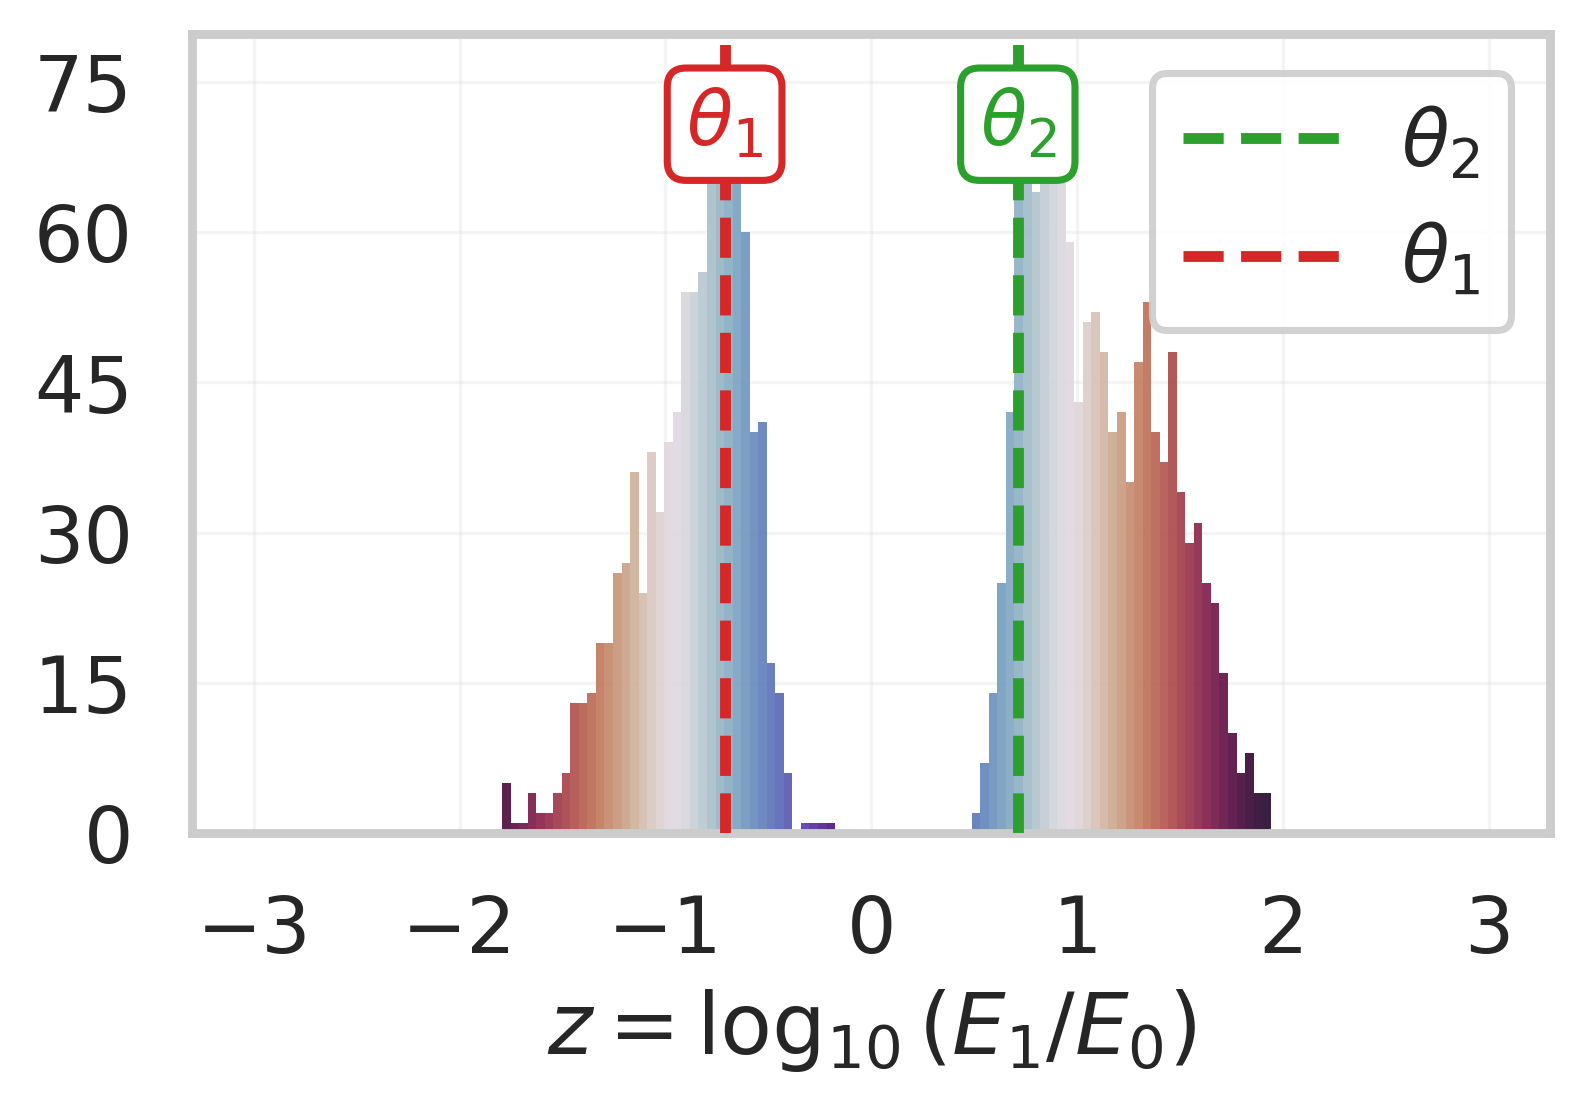

SNR: 7.667019844055176 dB


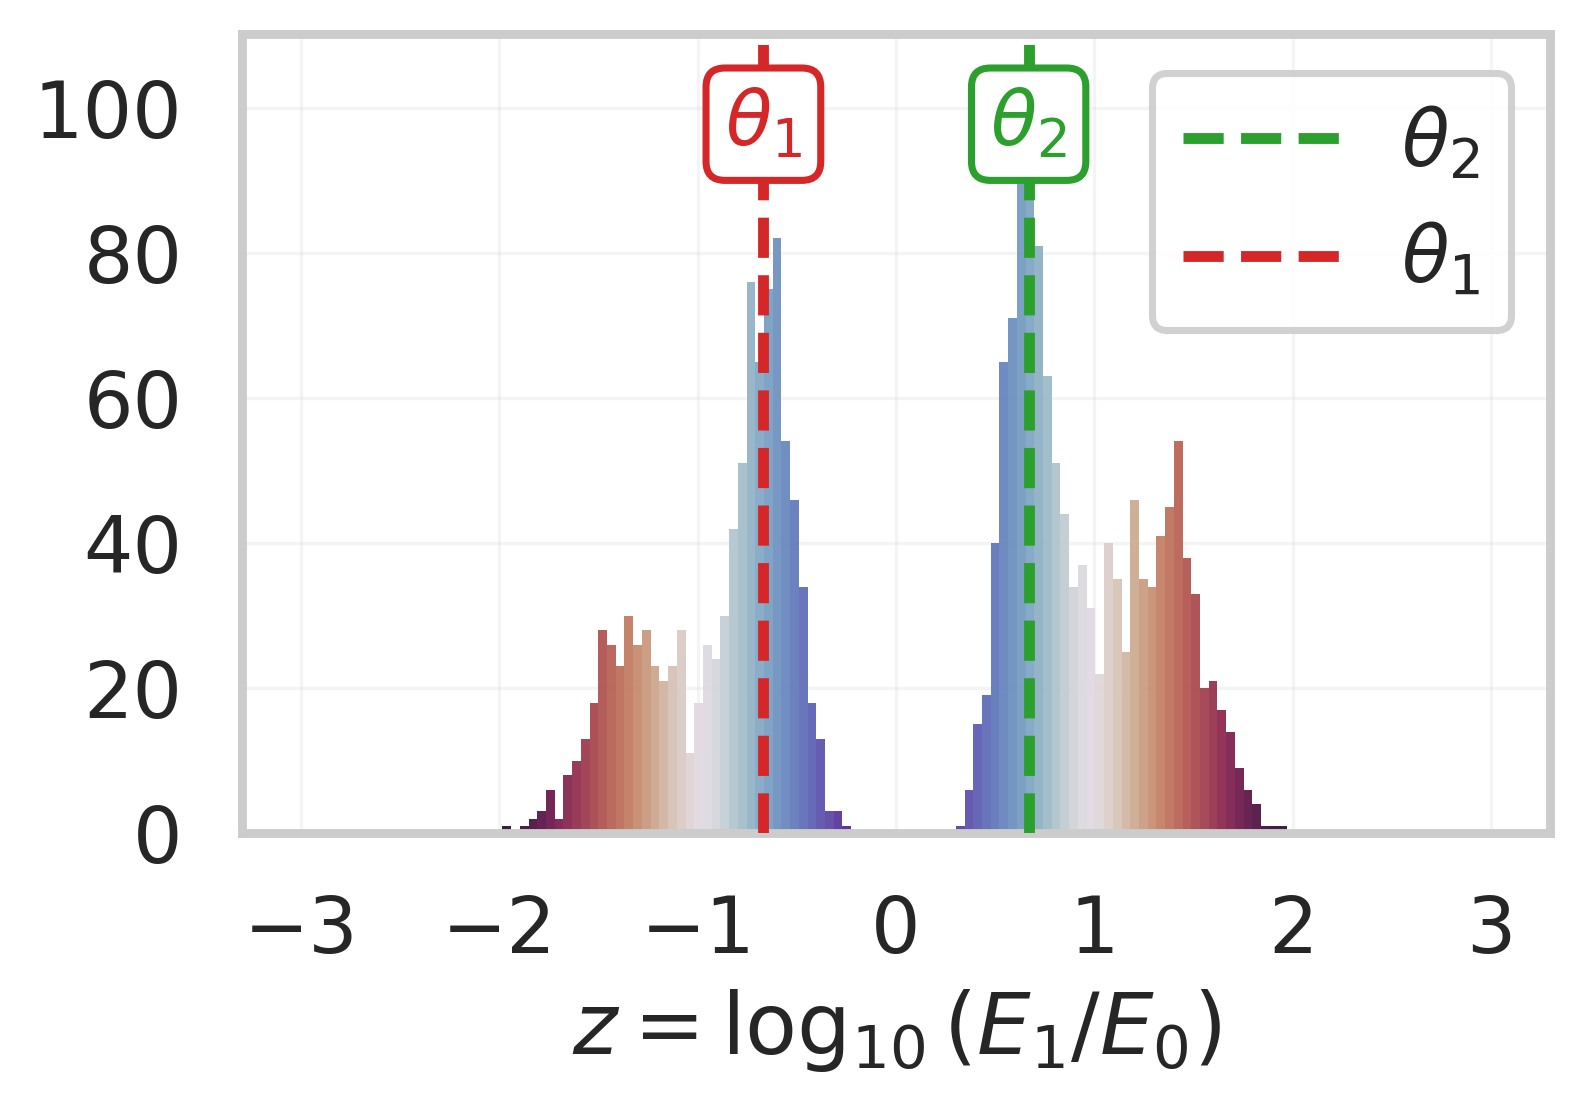

SNR: 7.889636516571045 dB


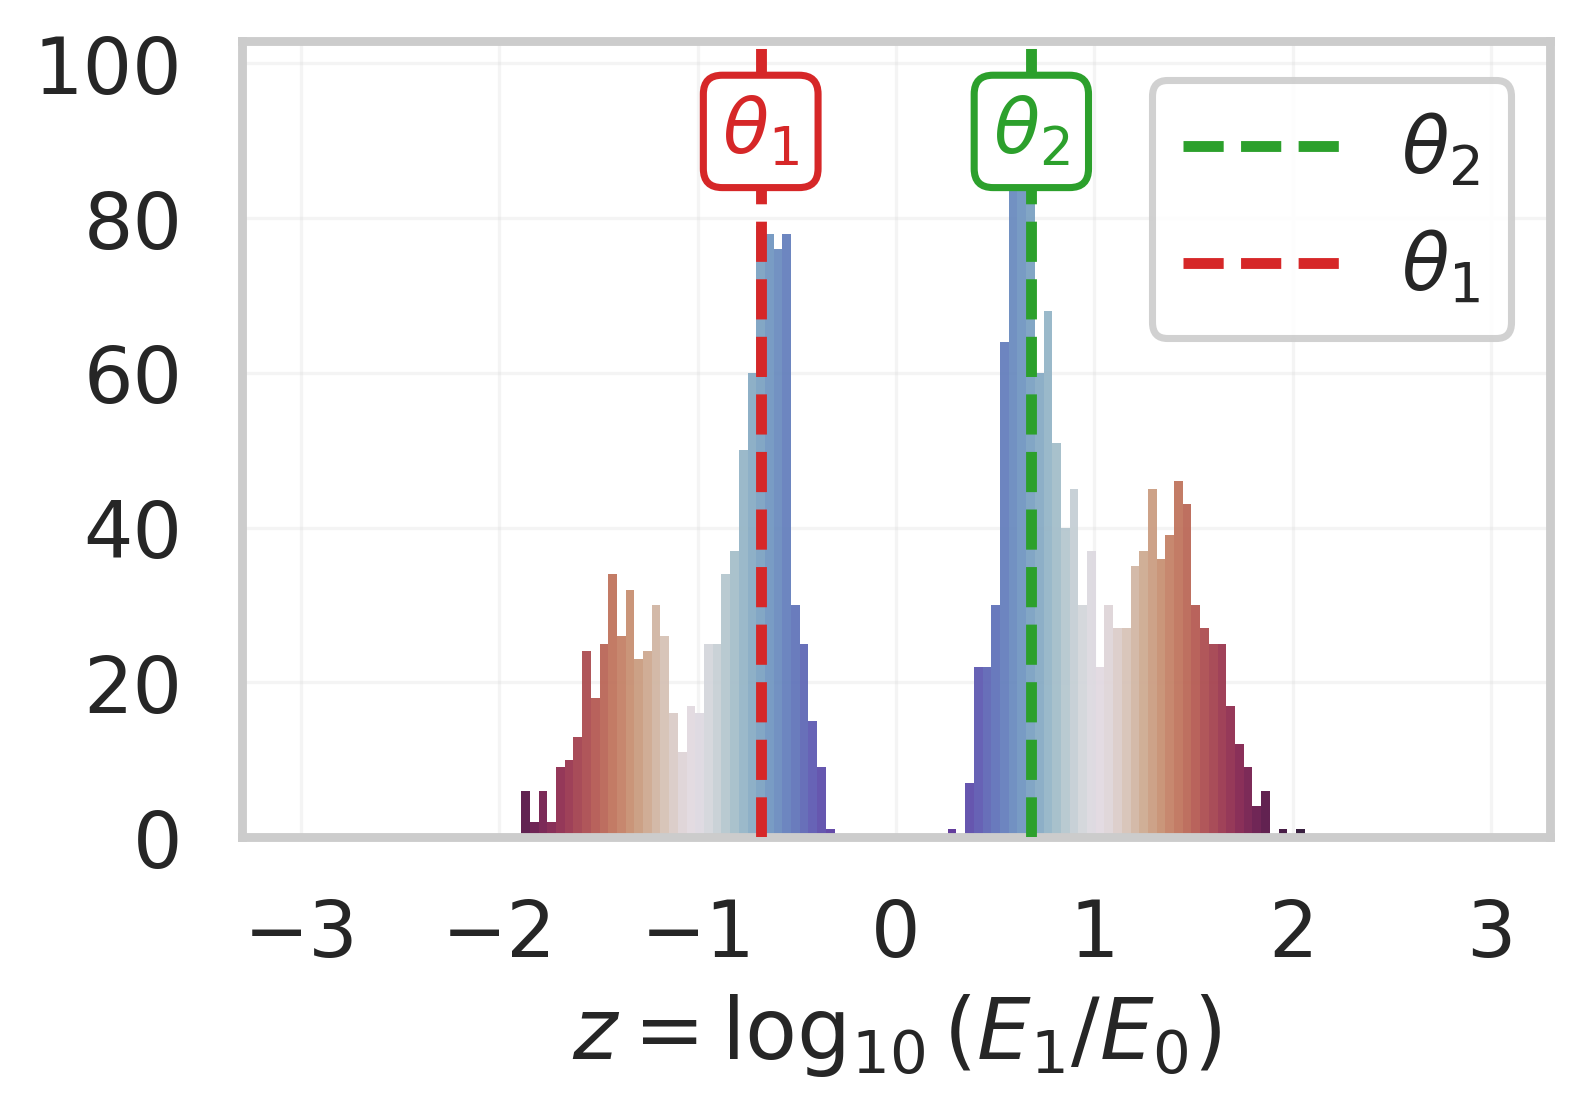

SNR: 7.931195259094238 dB


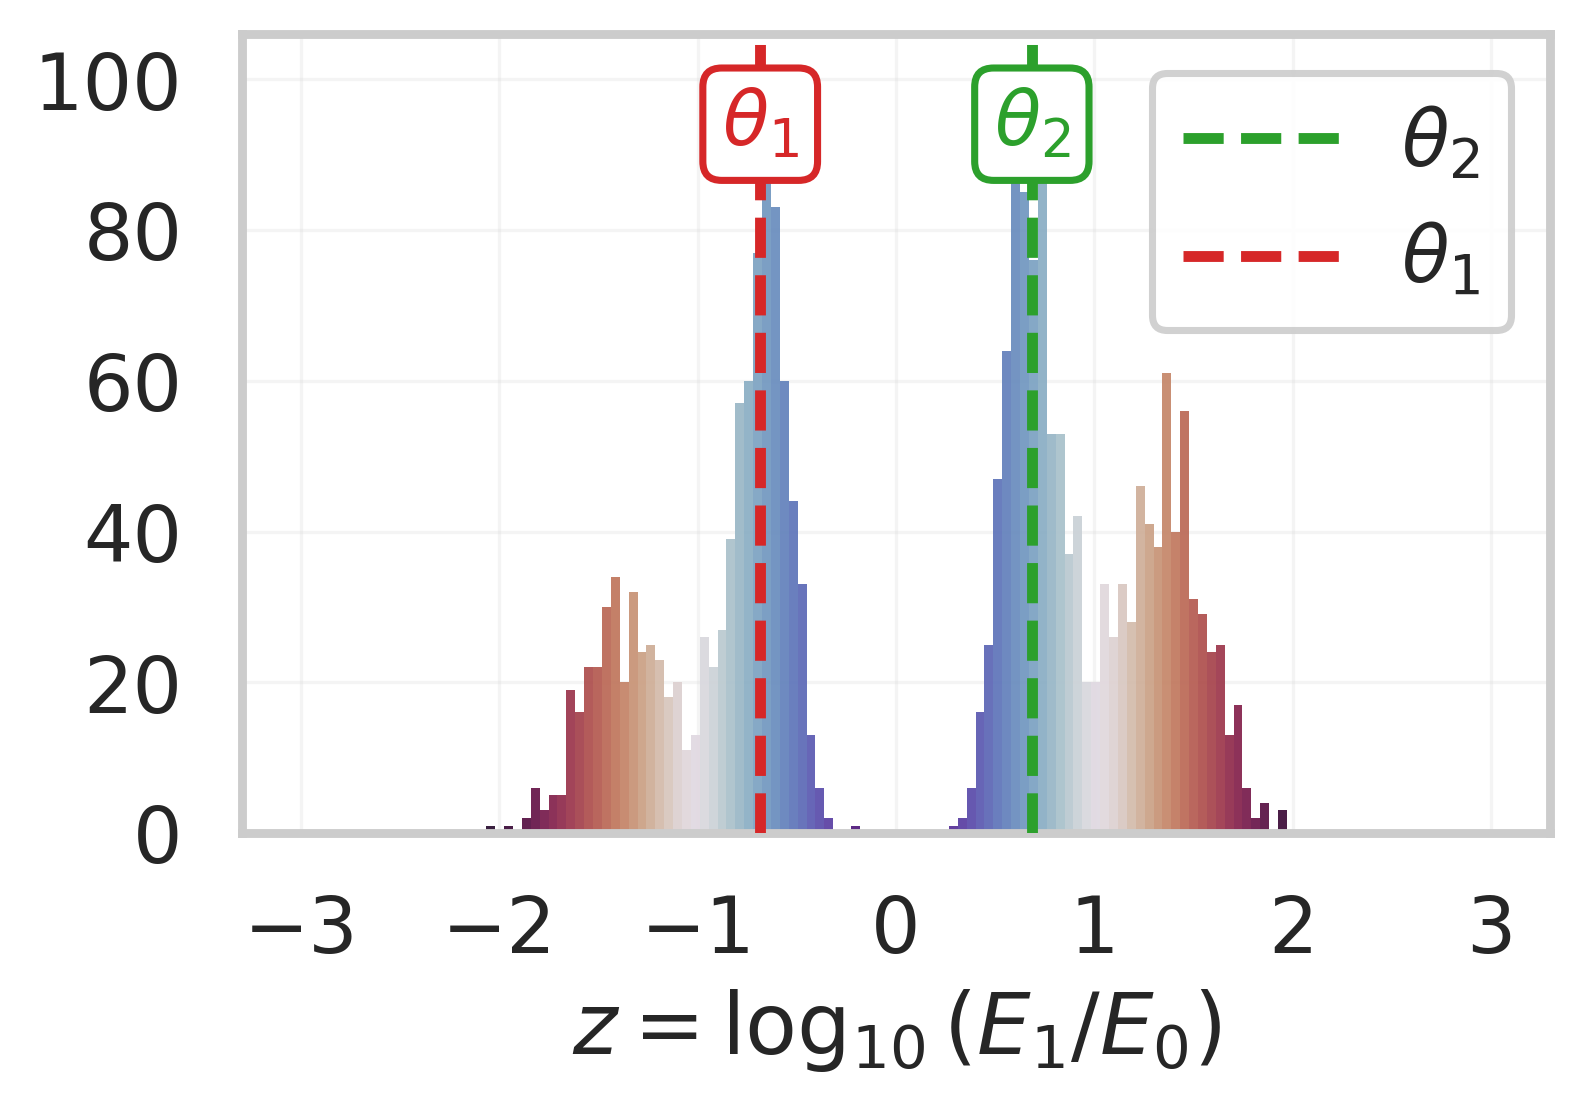

SNR: 7.947122573852539 dB


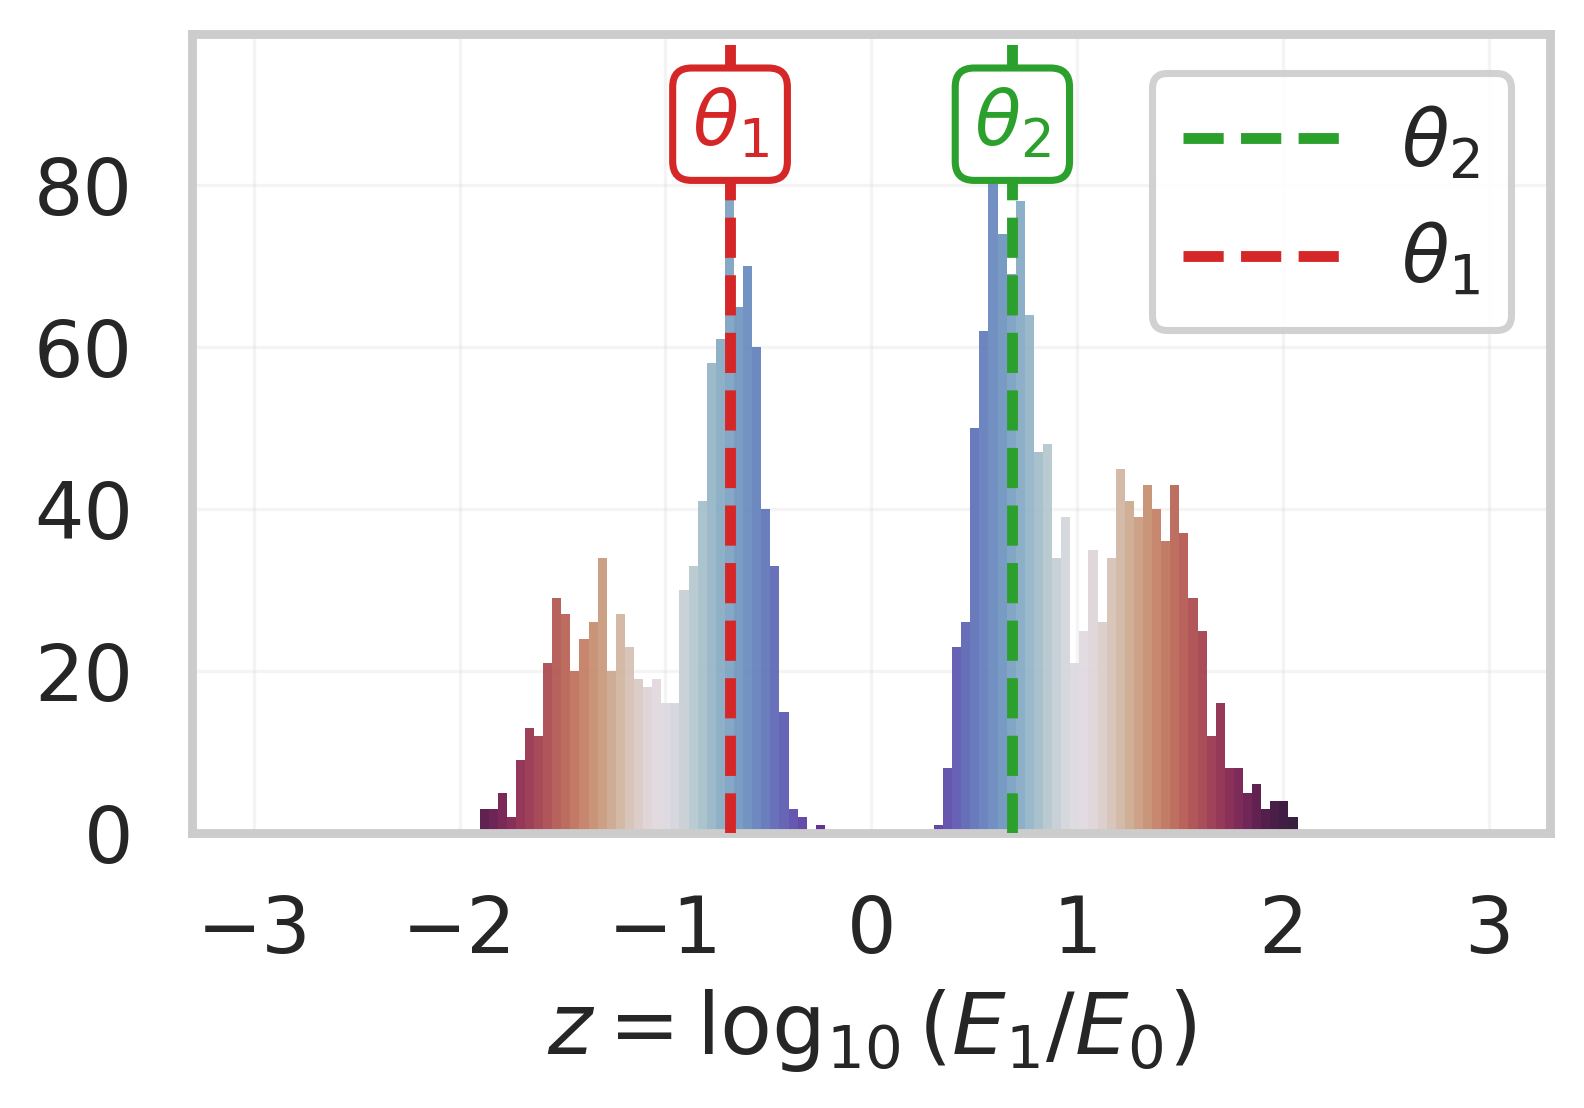

SNR: 7.957521915435791 dB


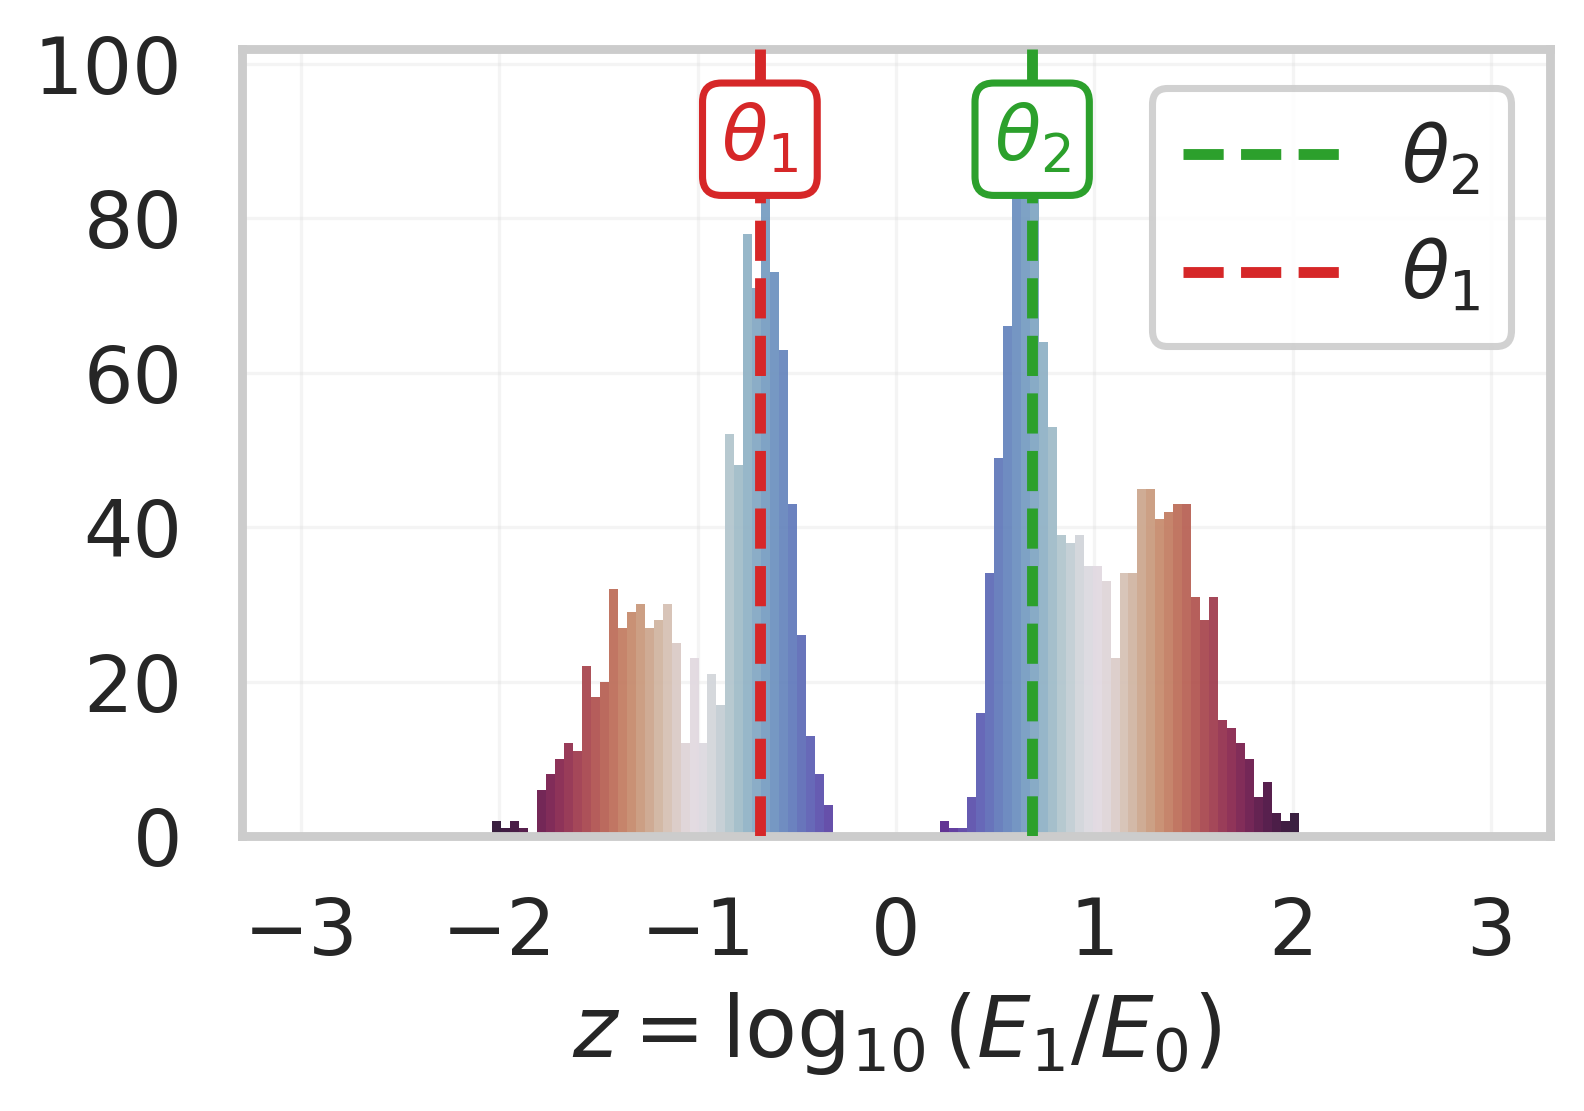

SNR: 7.965628147125244 dB


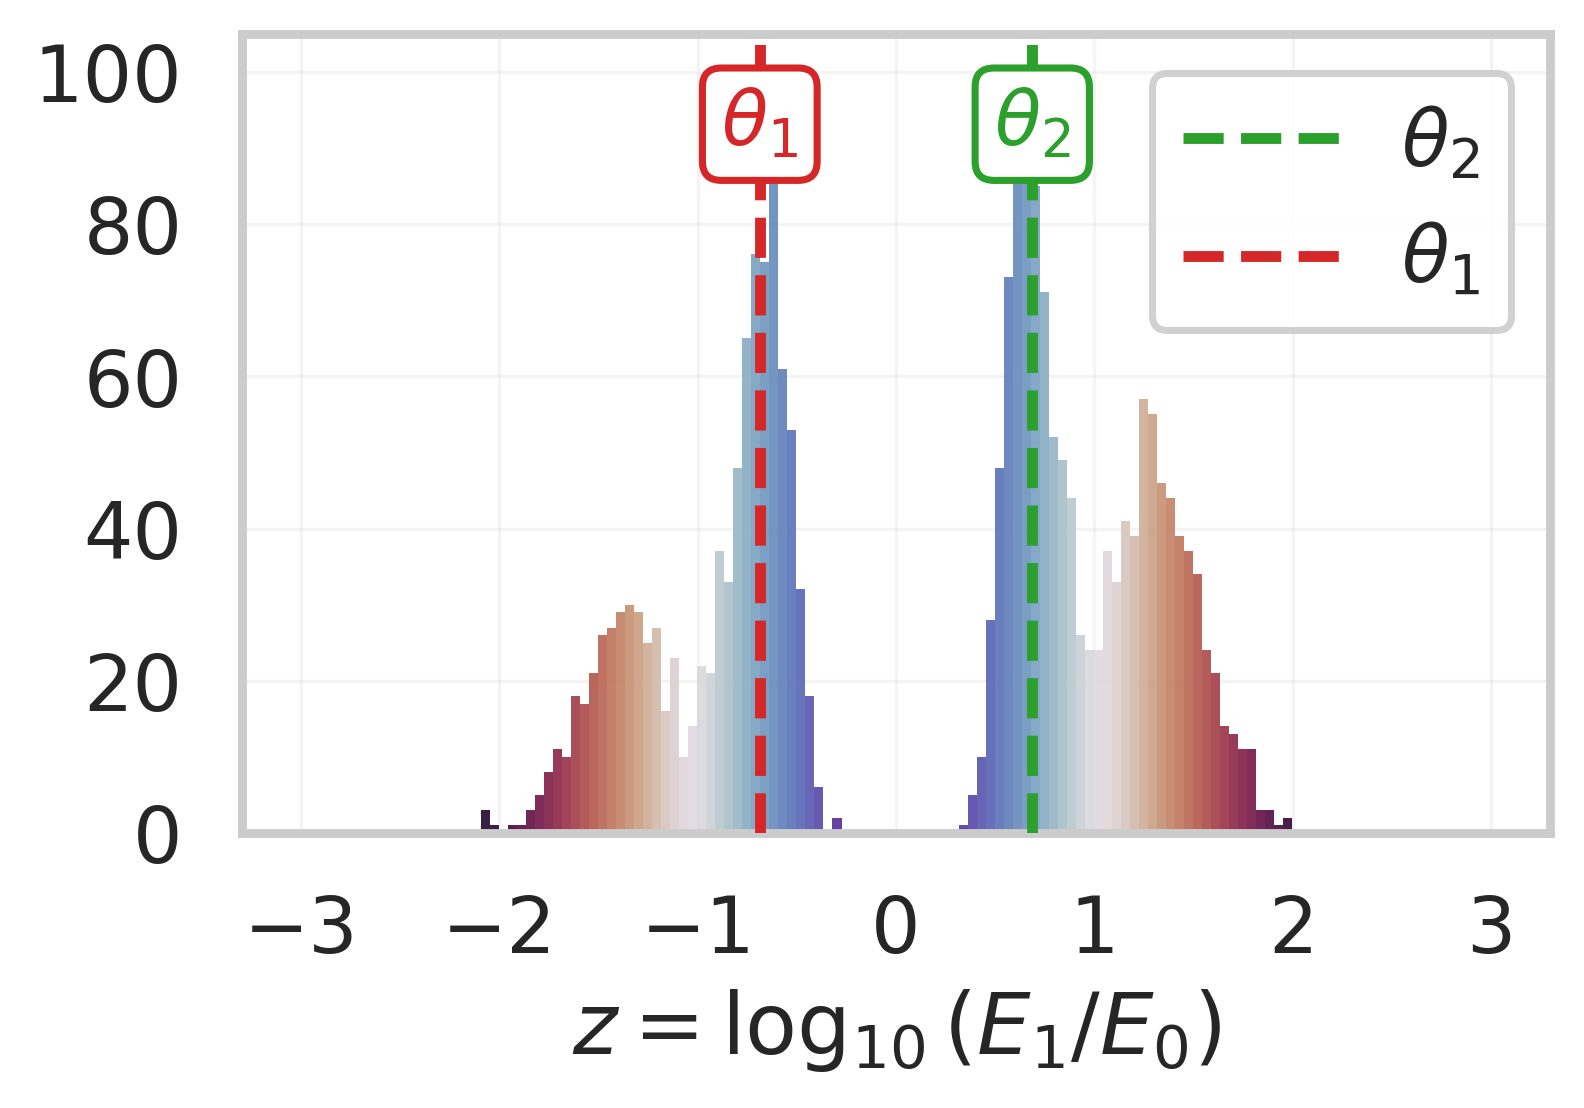

SNR: 7.973159313201904 dB


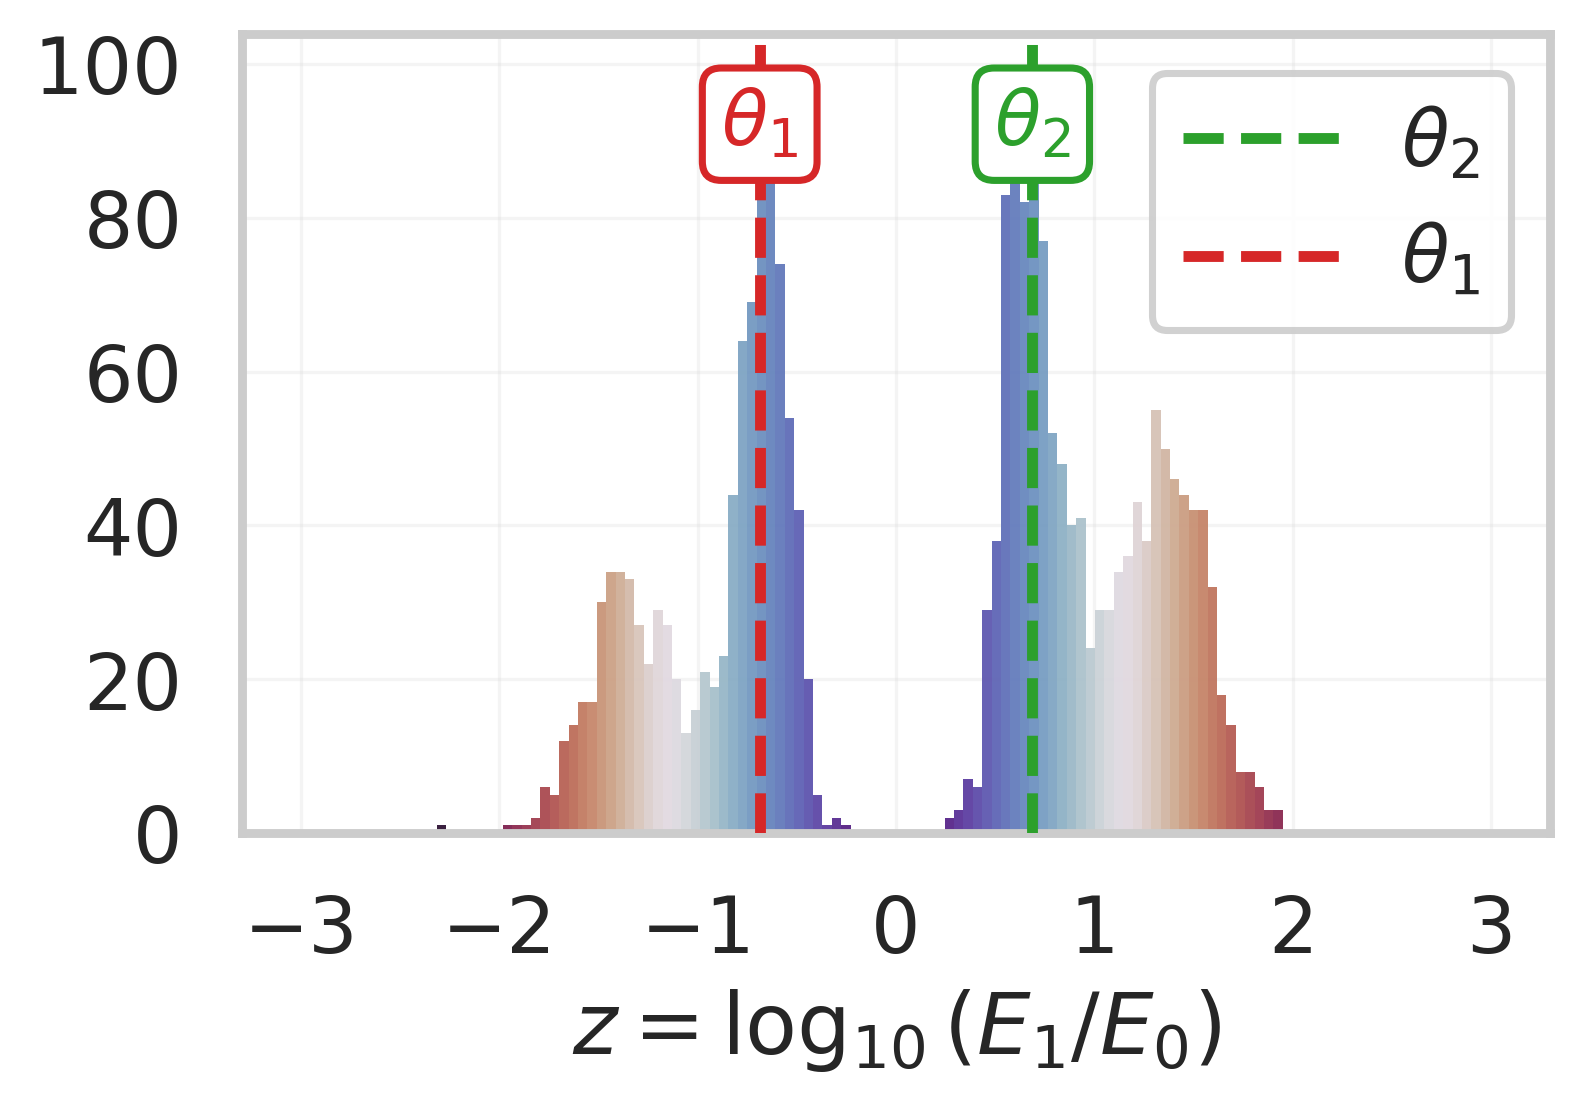

SNR: 7.981189727783203 dB


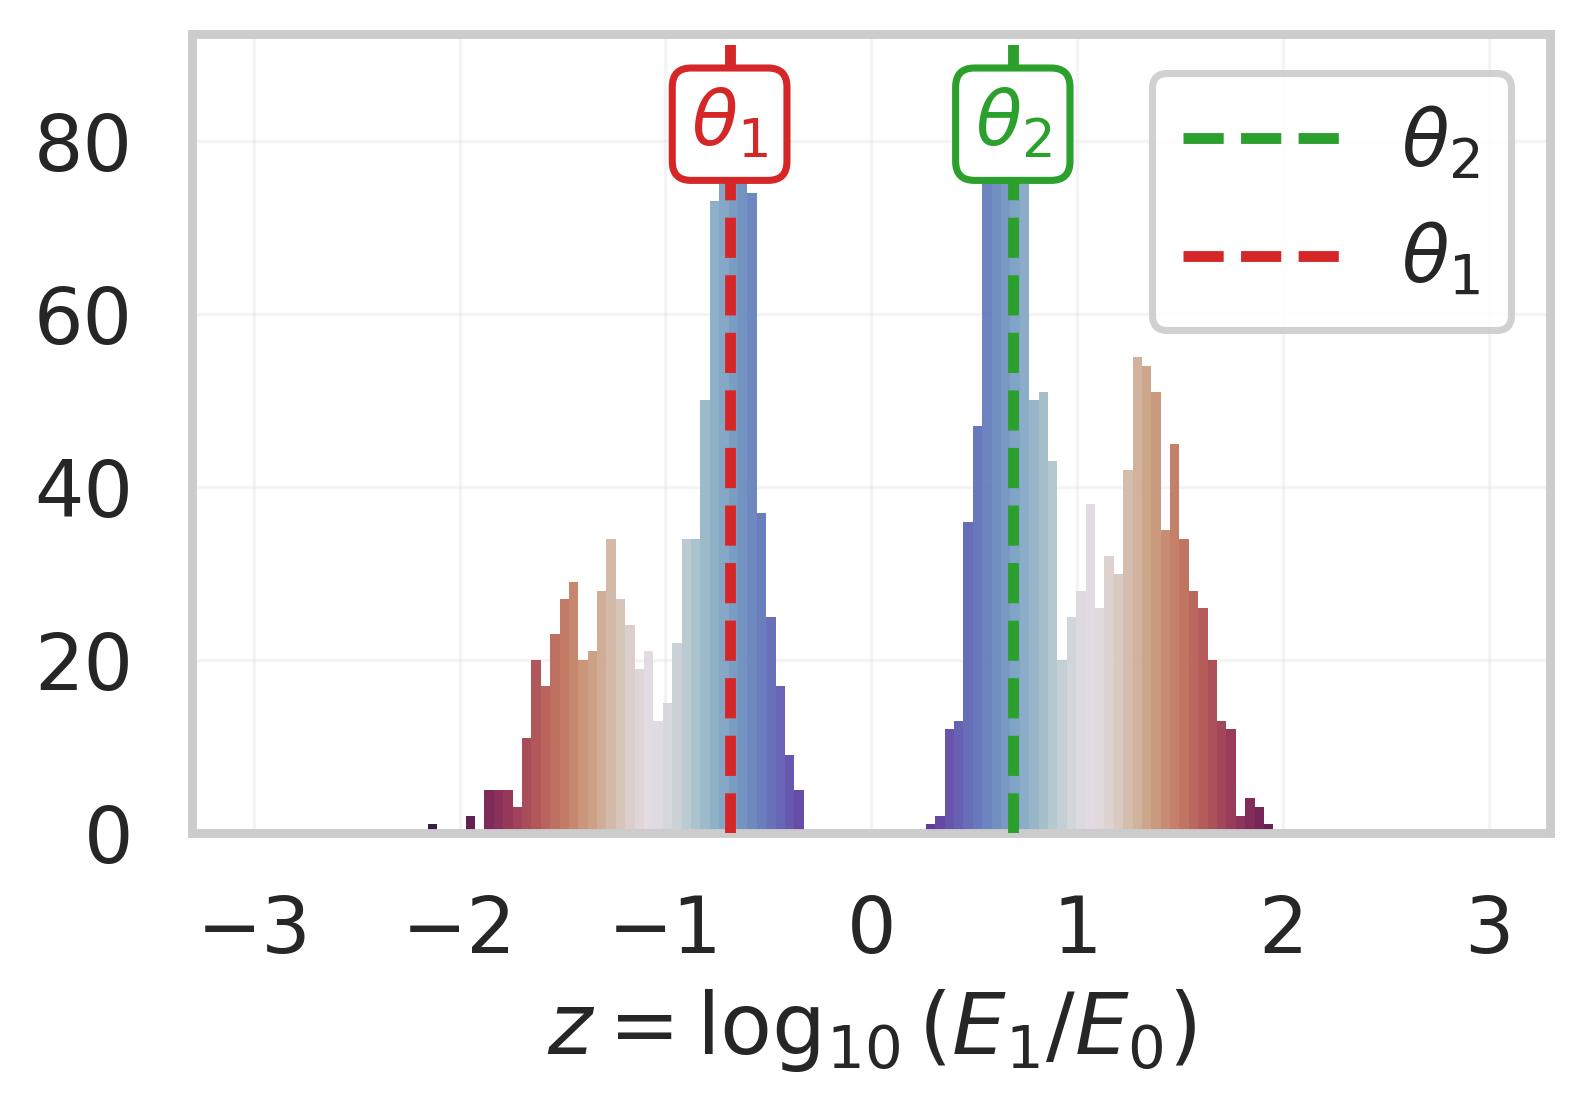

SNR: 7.989262104034424 dB


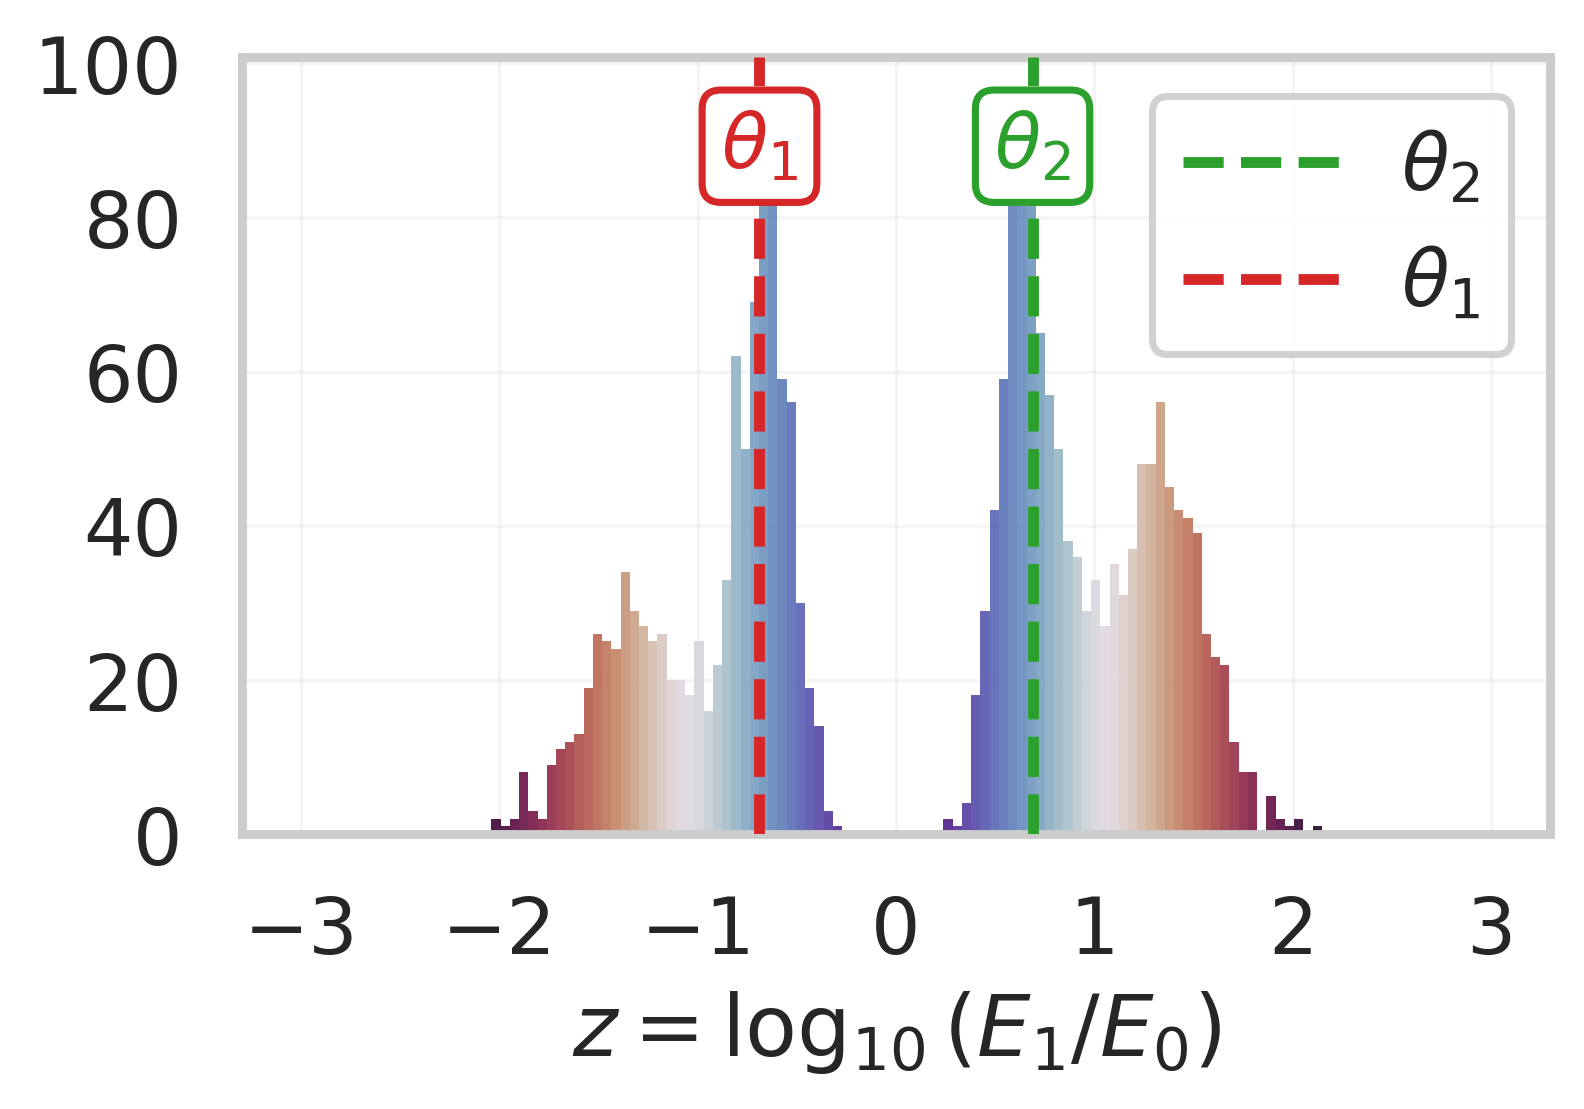

SNR: 8.000042915344238 dB


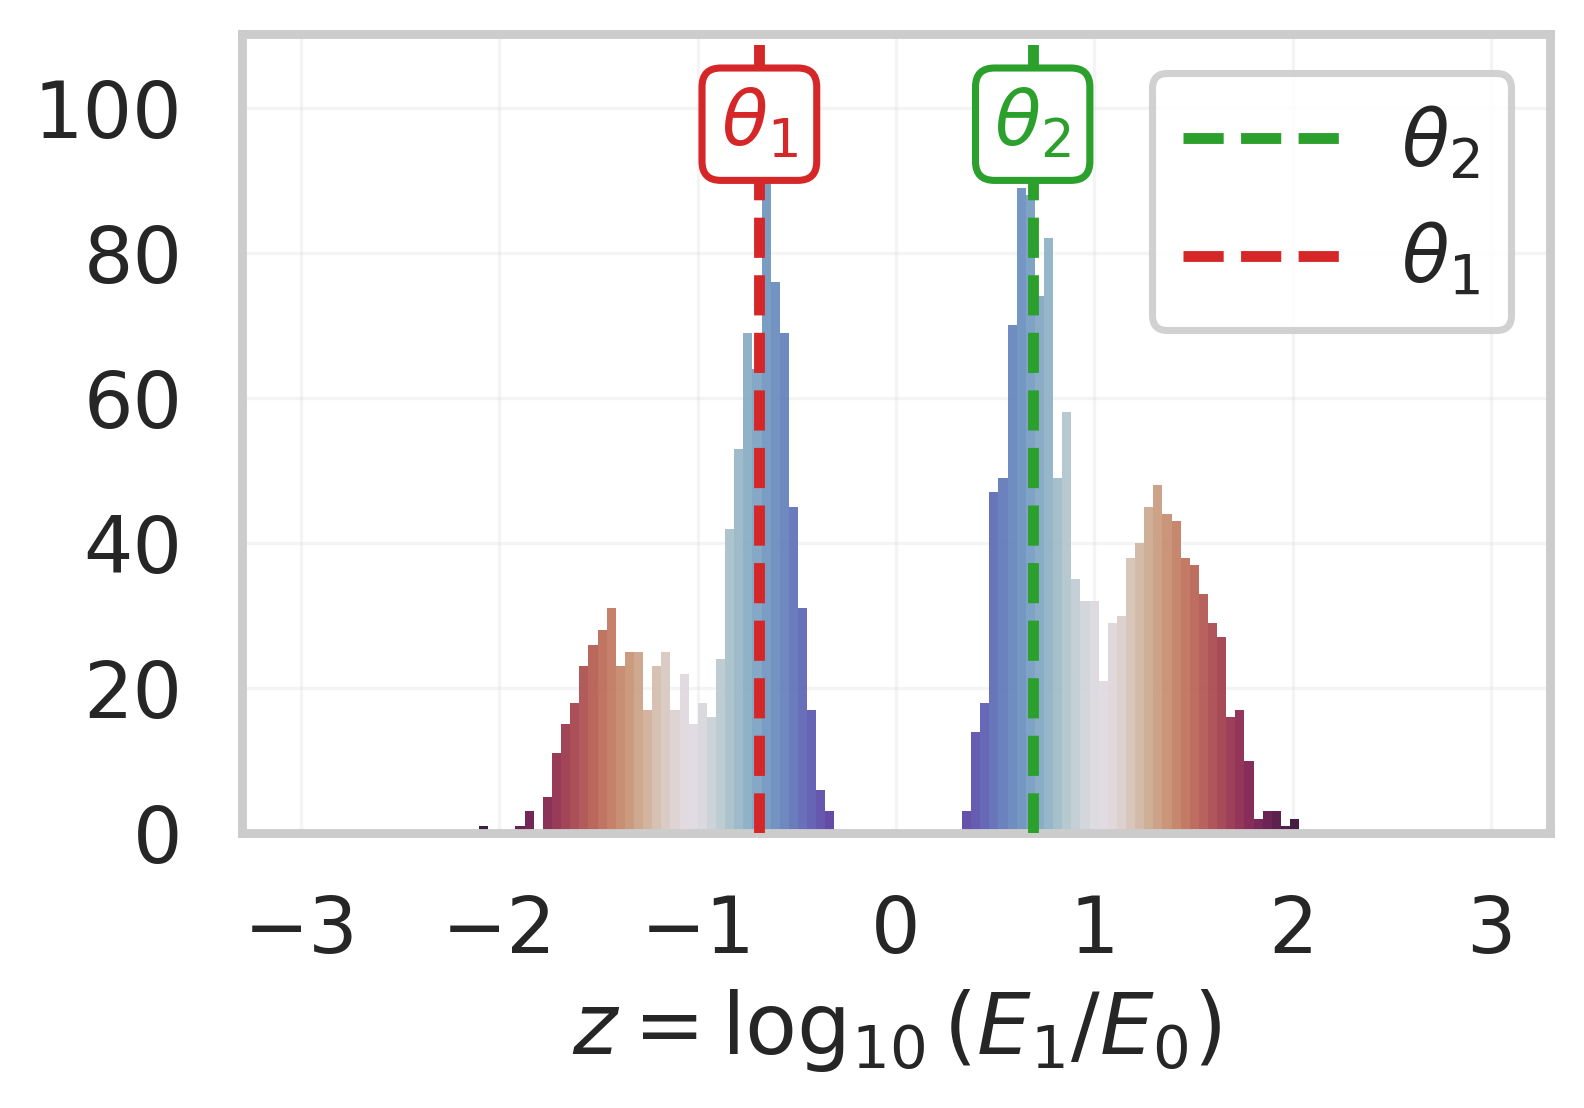

SNR: 8.016790390014648 dB


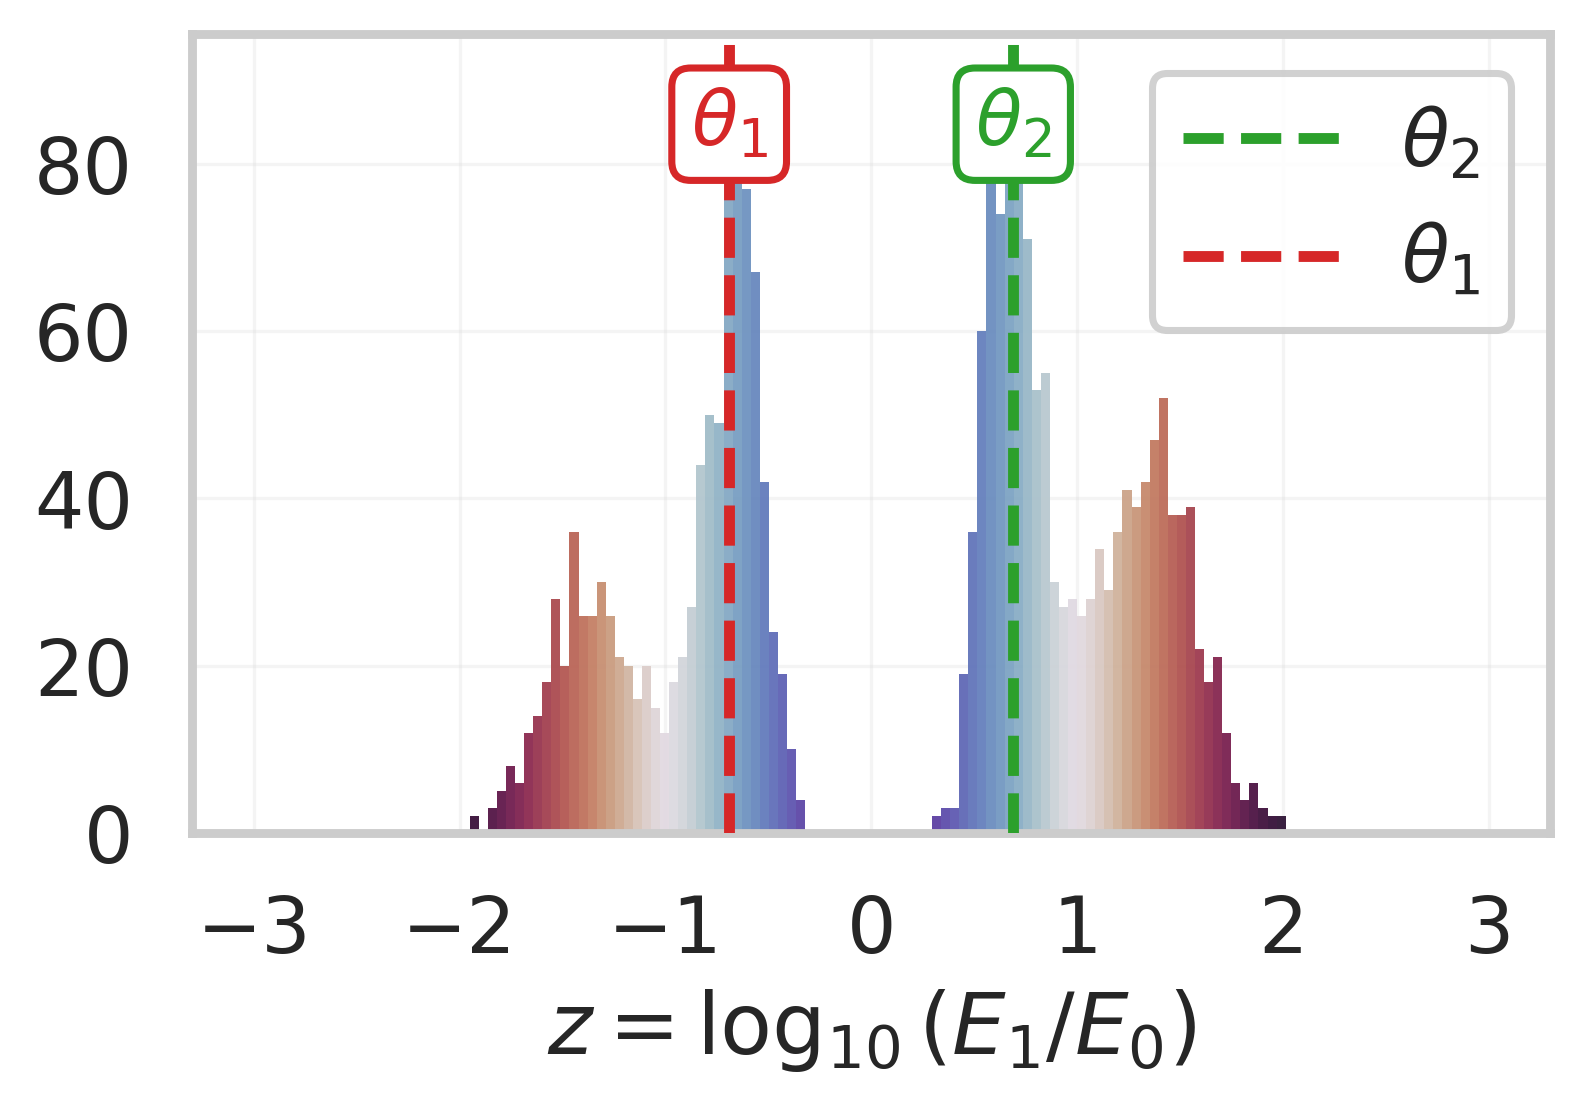

SNR: 8.075937271118164 dB


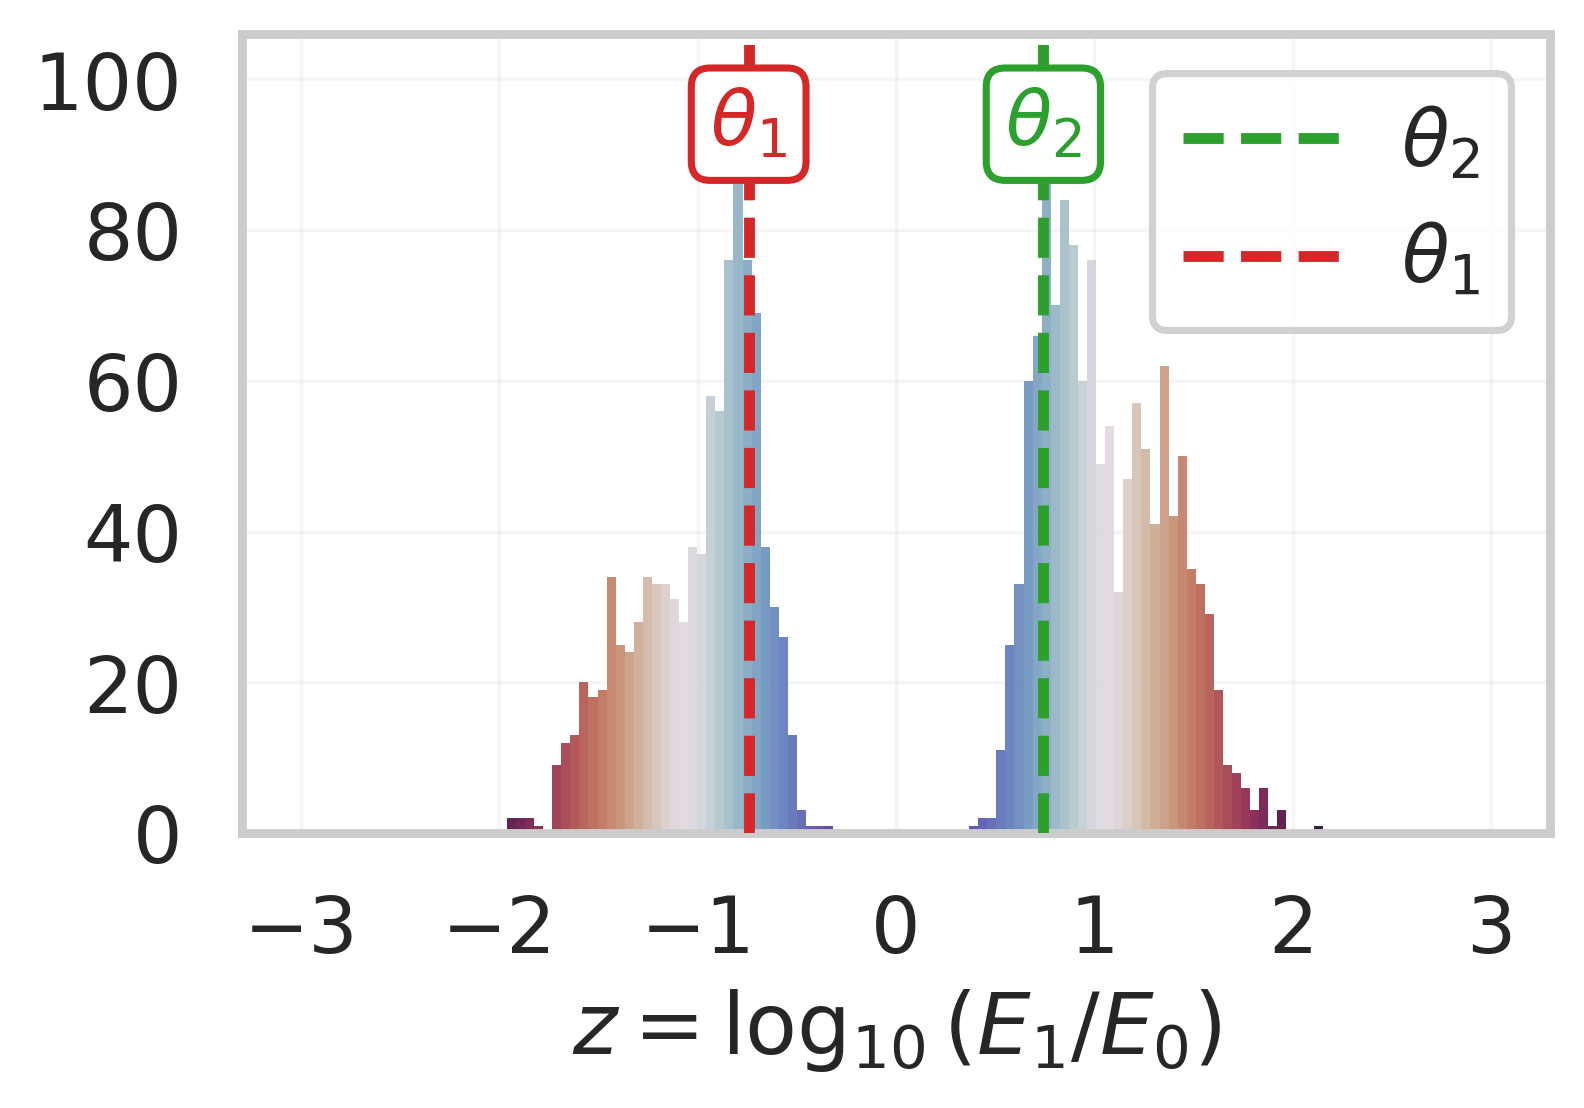

Error processing index 53146: 'float' object is not subscriptable
SNR: 8.345722198486328 dB


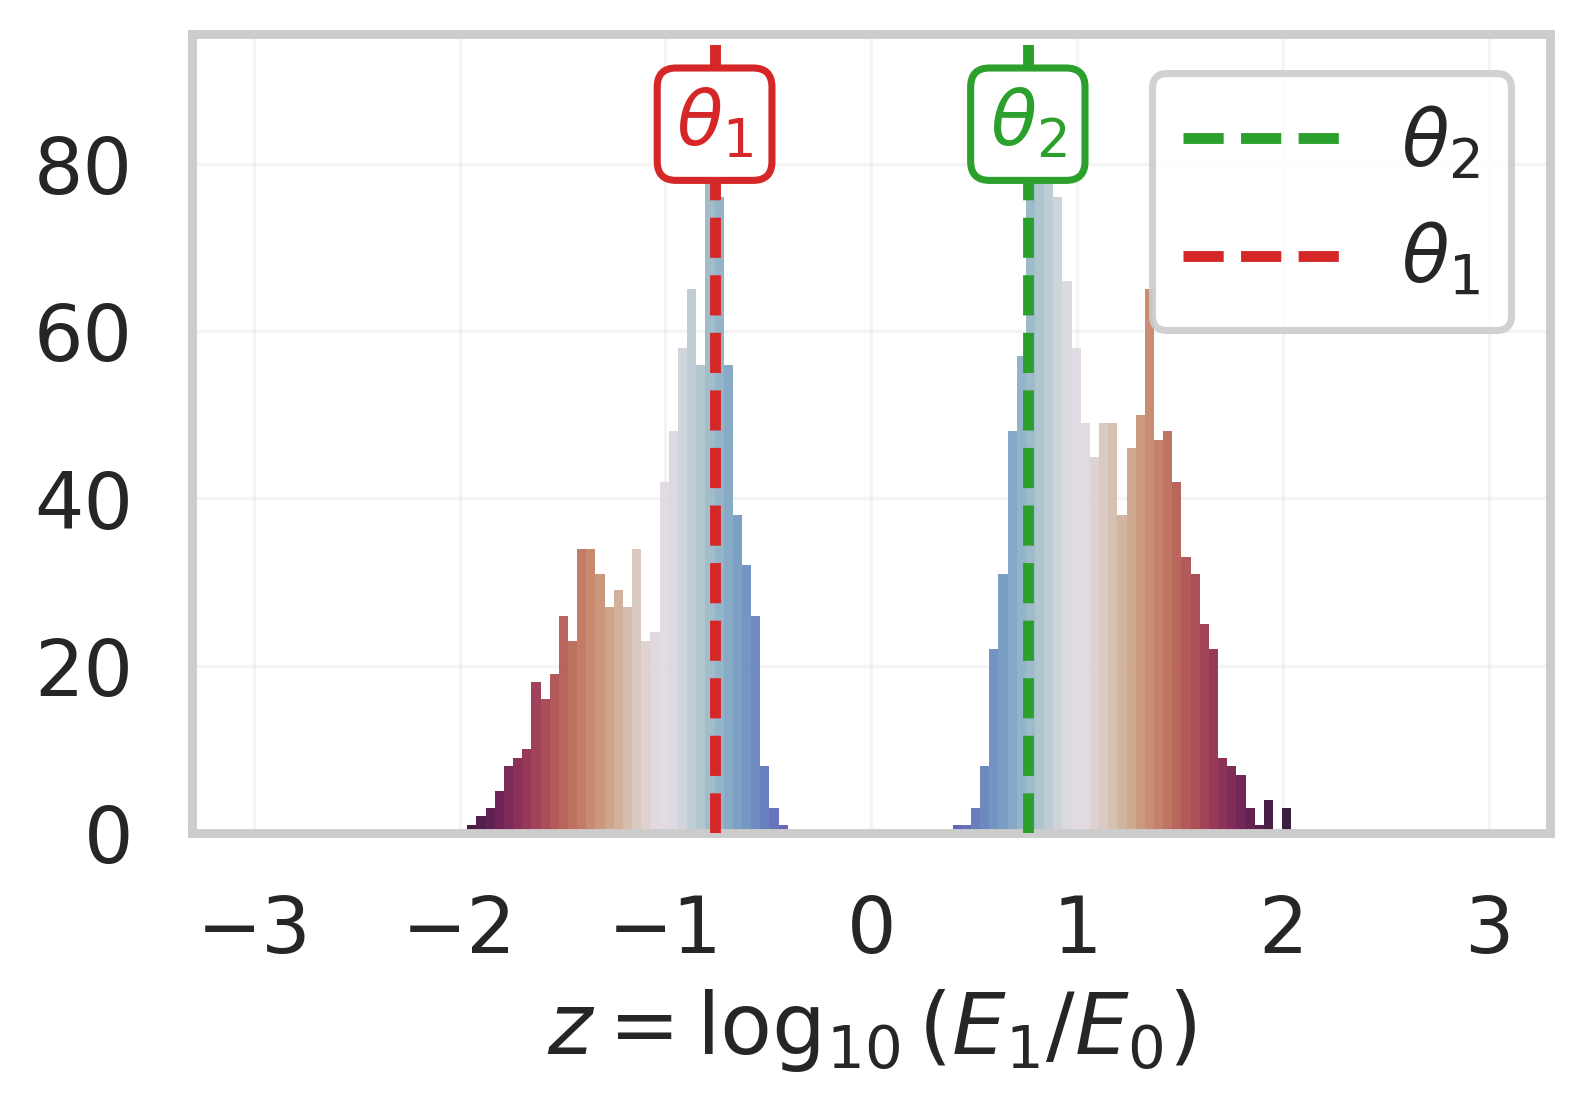

SNR: 8.472176551818848 dB


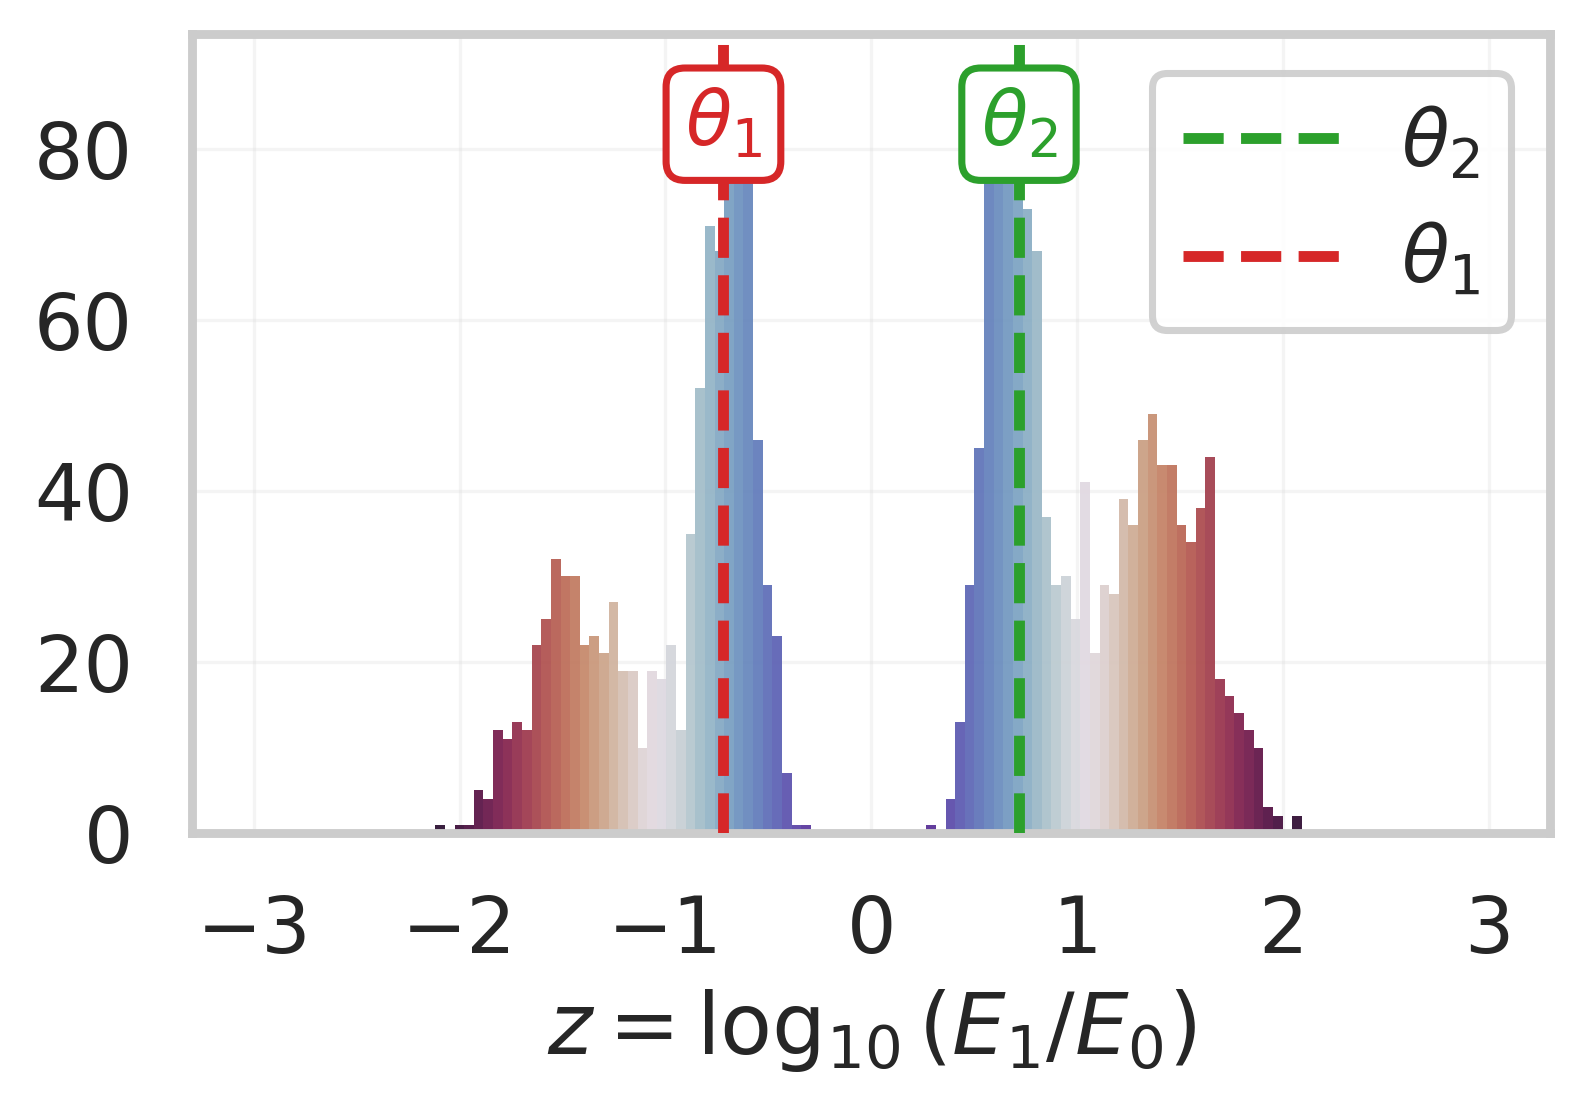

Error processing index 57701: 'float' object is not subscriptable
Error processing index 59220: 'float' object is not subscriptable


In [34]:
# db = client['r0_r1_SC_alpha_0_5_R=0_5_Encryption']
# phase_SC_col = db['destination, phase_1']
# df = pd.DataFrame(list(phase_SC_col.find({})))
# plot_histograms(df)

# db = client['MAC_SC']
# phase_SC_col = db['destination, phase_1']
# df = pd.DataFrame(list(phase_SC_col.find({})))
plot_histograms(df)

